In [32]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

# path to JADES catalog on HellBender 
cat_name = '/home/caltech-msanche3/data/JADES_fits_data.fits'

# path to translate file on HellBender
trans_file = '/home/caltech-msanche3/data'

jades_table = Table.read(cat_name, hdu='KRON_CONV',format='fits')
params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = jades_table
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 6

# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param"
# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'jades_run_hot_filtered_6'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/jades_trans_file.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 304366
F070W_KRON F090W_KRON_ei (363): jwst_nircam_f090w
F105W_KRON F105W_KRON_ei (202): hst/wfc3/IR/f105w.dat
F115W_KRON F115W_KRON_ei (364): jwst_nircam_f115w
F125W_KRON F125W_KRON_ei (203): hst/wfc3/IR/f125w.dat
F150W_KRON F150W_KRON_ei (365): jwst_nircam_f150w
F160W_KRON F160W_KRON_ei (205): hst/wfc3/IR/f160w.dat
F162M_KRON F162M_KRON_ei (369): jwst_nircam_f162m
F182M_KRON F182M_KRON_ei (370): jwst_nircam_f182m
F200W_KRON F200W_KRON_ei (366): jwst_nircam_f200w
F210M_KRON F210M_KRON_ei (371): jwst_nircam_f210m
F250M_KRON F250M_KRON_ei (379): jwst_nircam_f250m
F277W_KRON F277W_KRON_ei (375): jwst_nircam_f277w
F300M_KRON F300M_KRON_ei (380): jwst_nircam_f300m
F335M_KRON F335M_KRON_ei (381): jwst_nircam_f335m
F356W_KRON F356W_KRON_ei (3

Set sys_err = 0.03 (positive=True)
Template grid: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param (this may take some time)


100%|██████████| 6/6 [00:12<00:00,  2.10s/it]


Template   0: fsps_45k_t0.1_Av0.0.fits (NZ=1).
Template   1: fsps_45k_t0.1_Av0.5.fits (NZ=1).
Template   2: fsps_45k_t0.3_Av0.0.fits (NZ=1).
Template   3: fsps_45k_t0.3_Av0.5.fits (NZ=1).
Template   4: fsps_45k_t0.5_Av0.0.fits (NZ=1).
Template   5: fsps_45k_t0.5_Av0.5.fits (NZ=1).
Process templates: 17.261 s


62it [00:10,  5.80it/s]

Fitting program initialized successfully!


In [34]:
ez.set_sys_err(positive=True) 
chunk_size = 50000
cat_name = '/home/caltech-msanche3/data/JADES_fits_data.fits'
hdul2 = fits.open(cat_name,memap=True)
cat = Table(hdul2['PHOTOZ_KRON'].data)
total_obj = 0
# 2. Fit the 6<z<13 objects
print('Fitting catalog in chunks...')
# total objects: 304366
# split into chunks
for i in range(0, 304366, chunk_size):
    print(f'Fitting chunk {i//chunk_size + 1}...')
    chunk = ez.idx[i : i + chunk_size]
    sample = 6 < cat[i : i + chunk_size]['z_a']
    ct = 0
    for j in sample:
        if j:
            ct+=1
    total_obj = total_obj + ct
    print('ct= ',ct)
    print("total= ",total_obj)
    ez.fit_catalog(chunk[sample],n_proc=16)

print('Catalog fitted successfully!')



Set sys_err = 0.03 (positive=True)
Fitting catalog in chunks...
Fitting chunk 1...
ct=  5563
total=  5563


100%|██████████| 62/62 [00:01<00:00, 35.29it/s]


Compute best fits
fit_best: 0.6 s (n_proc=1,  NOBJ=4891)
Fit 3.2 s (n_proc=16, NOBJ=5563)
Fitting chunk 2...
ct=  6769
total=  12332


100%|██████████| 62/62 [00:02<00:00, 29.13it/s]


Compute best fits
fit_best: 1.2 s (n_proc=1,  NOBJ=10606)
Fit 4.3 s (n_proc=16, NOBJ=6769)
Fitting chunk 3...
ct=  9461
total=  21793


...

Compute best fits
fit_best: 1.8 s (n_proc=2,  NOBJ=26298)
Fit 5.1 s (n_proc=16, NOBJ=7590)
Fitting chunk 6...
ct=  14004
total=  45949


100%|██████████| 62/62 [00:04<00:00, 14.78it/s]


Compute best fits
fit_best: 1.7 s (n_proc=3,  NOBJ=37284)
Fit 7.0 s (n_proc=16, NOBJ=14004)
Fitting chunk 7...
ct=  1433
total=  47382


100%|██████████| 62/62 [00:00<00:00, 116.69it/s]


Compute best fits
fit_best: 1.8 s (n_proc=3,  NOBJ=38440)
Fit 3.4 s (n_proc=16, NOBJ=1433)
Catalog fitted successfully!


In [35]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=True,
    beta_prior=True, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:1136: RuntimeWarning: divide by zero encountered in log
  ln_fit_beta_y = np.log(fit_beta_y)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1540: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


fit_best: 6.6 s (n_proc=3,  NOBJ=37865)


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4008: RuntimeWarning: overflow encountered in exp
  pzcum = cumtrapz(np.exp(spl(zgrid_zoom)), x=zgrid_zoom, axis=1)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4014: RuntimeWarning: invalid value encountered in divide
  pzcum = (pzcum.T / pzcmax).T


Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 37865/37865 [02:28<00:00, 254.19it/s]
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4285: RuntimeWarning: invalid value encountered in divide
  coeffs_norm = (coeffs_norm.T/coeffs_norm.sum(axis=1)).T


template called: /home/caltech-msanche3/data/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param.fits


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4320: RuntimeWarning: invalid value encountered in divide
  draws_norm = (draws_norm.T/draws_norm.sum(axis=2).T).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4650: RuntimeWarning: invalid value encountered in divide
  par_draws_table['ssfr'] = (par_draws_table['sfr'] /


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


/tmp/ipykernel_340170/3671339313.py:2: RuntimeWarning: divide by zero encountered in divide
  uv = -2.5*np.log10(zout['restU'][0:n]/zout['restV'][0:n])
/tmp/ipykernel_340170/3671339313.py:2: RuntimeWarning: invalid value encountered in divide
  uv = -2.5*np.log10(zout['restU'][0:n]/zout['restV'][0:n])
/tmp/ipykernel_340170/3671339313.py:2: RuntimeWarning: divide by zero encountered in log10
  uv = -2.5*np.log10(zout['restU'][0:n]/zout['restV'][0:n])
/tmp/ipykernel_340170/3671339313.py:2: RuntimeWarning: invalid value encountered in log10
  uv = -2.5*np.log10(zout['restU'][0:n]/zout['restV'][0:n])
/tmp/ipykernel_340170/3671339313.py:3: RuntimeWarning: divide by zero encountered in divide
  vj = -2.5*np.log10(zout['restV'][0:n]/zout['restJ'][0:n])
/tmp/ipykernel_340170/3671339313.py:3: RuntimeWarning: invalid value encountered in divide
  vj = -2.5*np.log10(zout['restV'][0:n]/zout['restJ'][0:n])
/tmp/ipykernel_340170/3671339313.py:3: RuntimeWarning: divide by zero encountered in log10
  

Text(0, 0.5, '$(U-V)_0$')

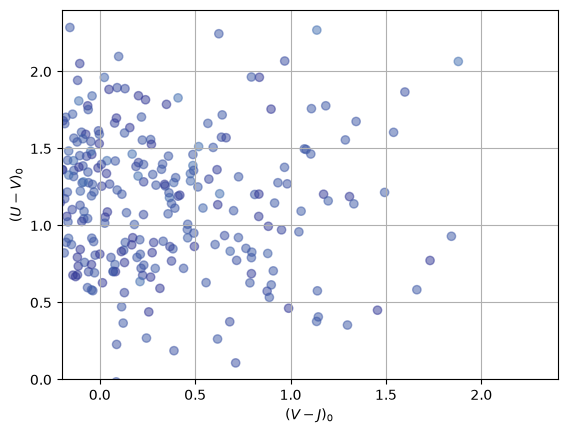

In [7]:
n = 300000  # num of objs to graph
uv = -2.5*np.log10(zout['restU'][0:n]/zout['restV'][0:n])
vj = -2.5*np.log10(zout['restV'][0:n]/zout['restJ'][0:n])
ssfr = zout['sfr'][0:n]/zout['mass'][0:n]


sel = (zout['z_phot'][0:n] > 0.2) & (zout['z_phot'][0:n] < 1)
plt.scatter(vj[sel], uv[sel], c=np.log10(ssfr)[sel], 
            vmin=-13, vmax=-8, alpha=0.5, cmap='RdYlBu')

plt.xlim(-0.2, 2.4); plt.ylim(0, 2.4); plt.grid()
plt.xlabel(r'$(V-J)_0$'); plt.ylabel(r'$(U-V)_0$')  

/tmp/ipykernel_340170/3142945514.py:6: RuntimeWarning: invalid value encountered in log10
  imag = 31.40 - 2.5*np.log10(ez.cat[ifilter])


[-1. -1. -1. ... -1. -1. -1.]


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:2869: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


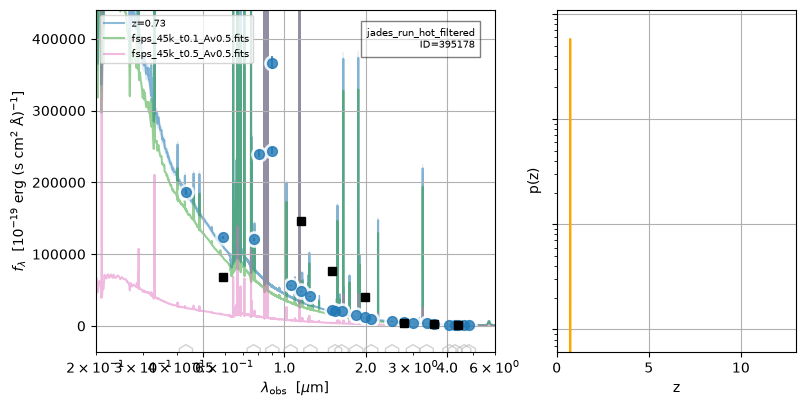

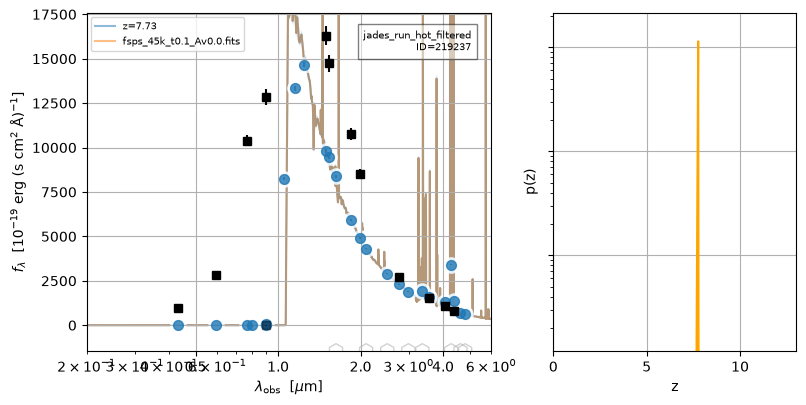

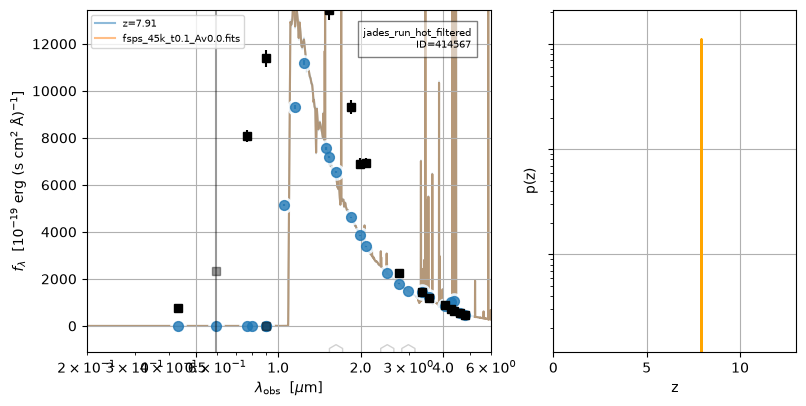

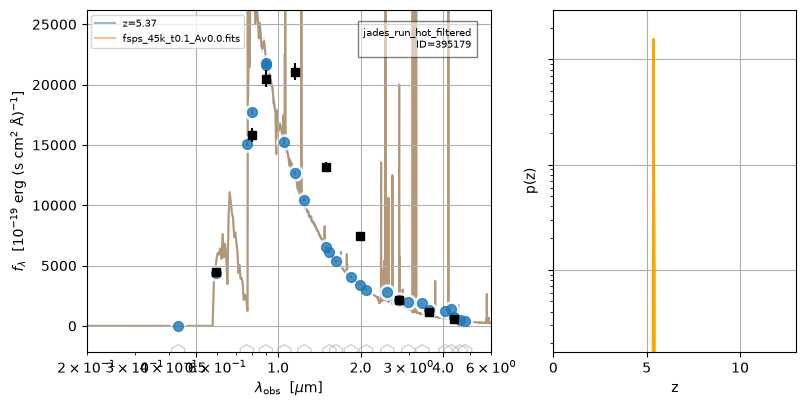

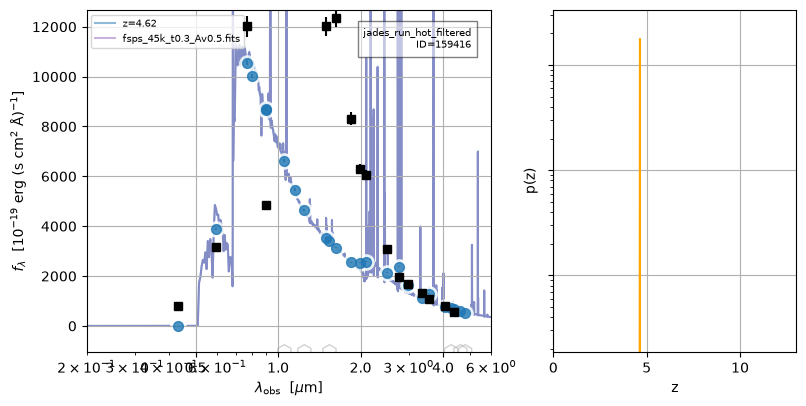

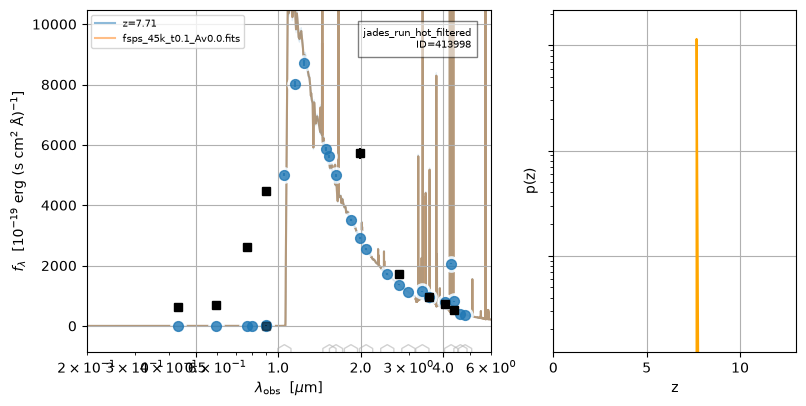

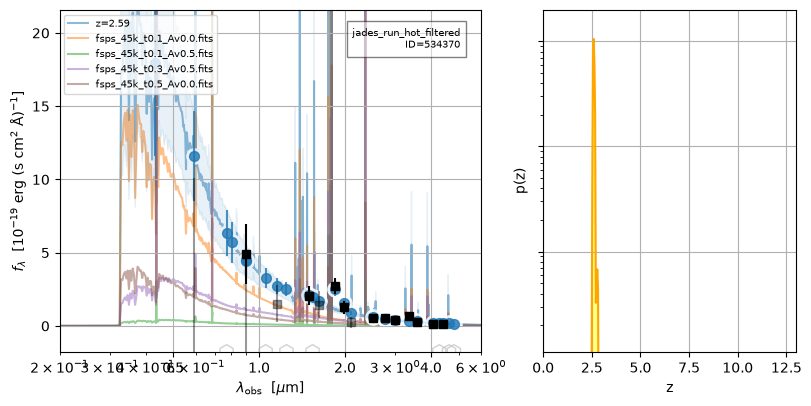

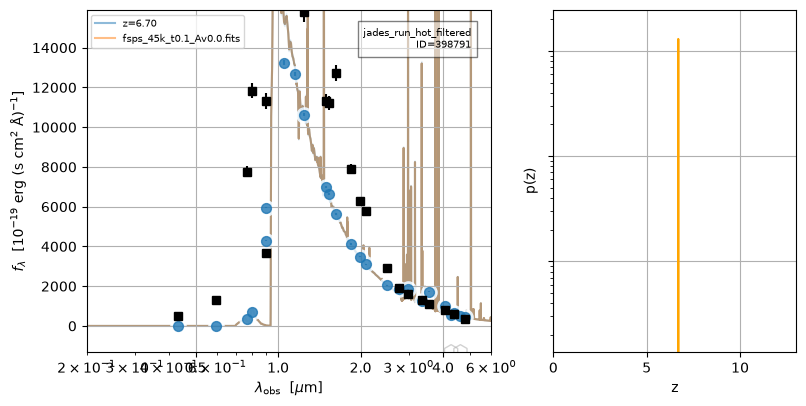

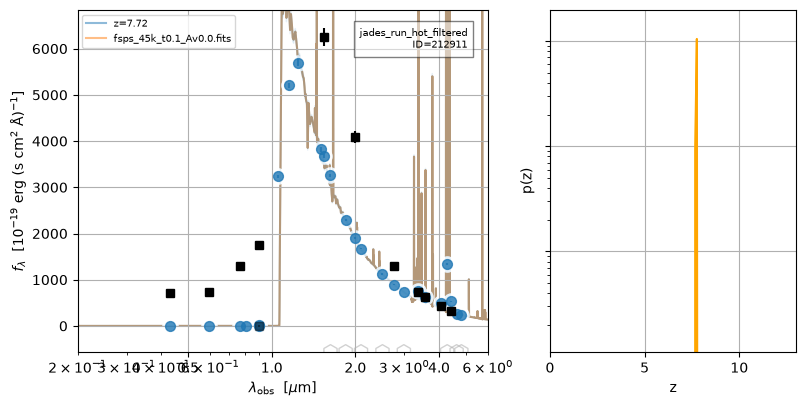

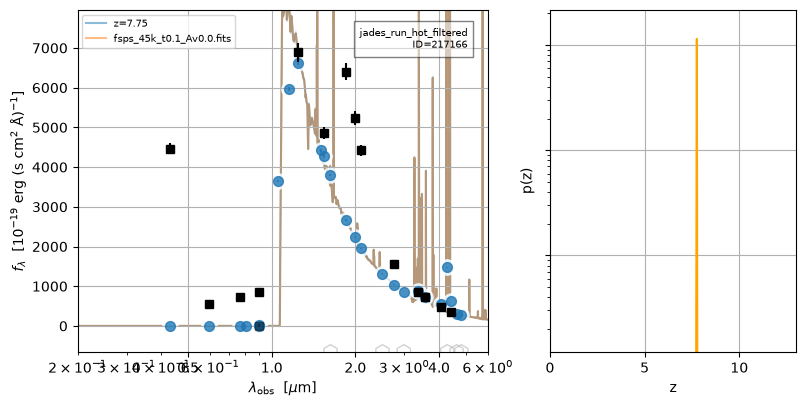

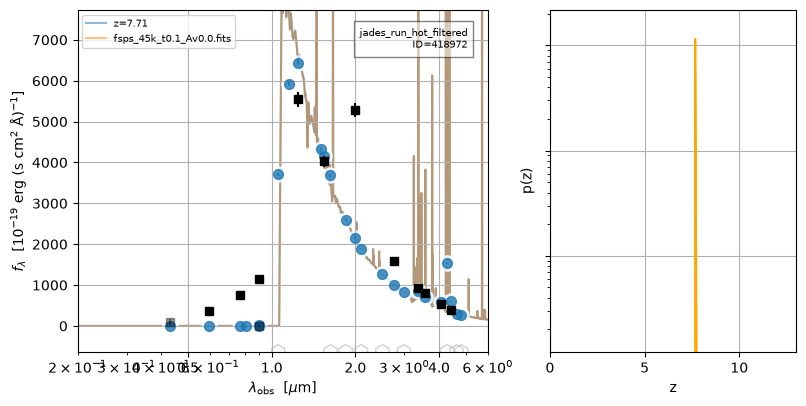

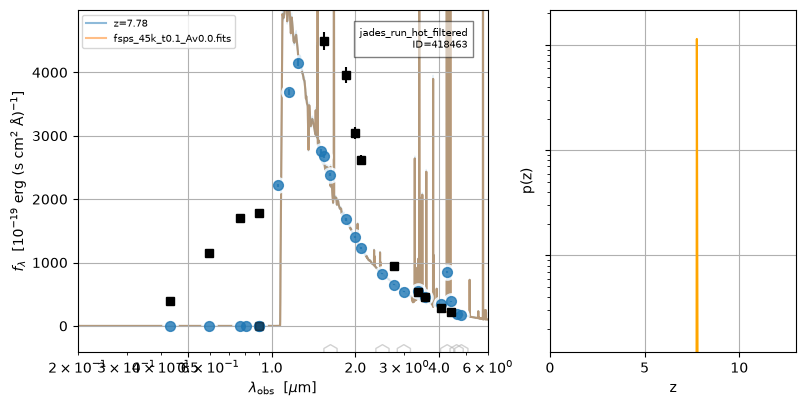

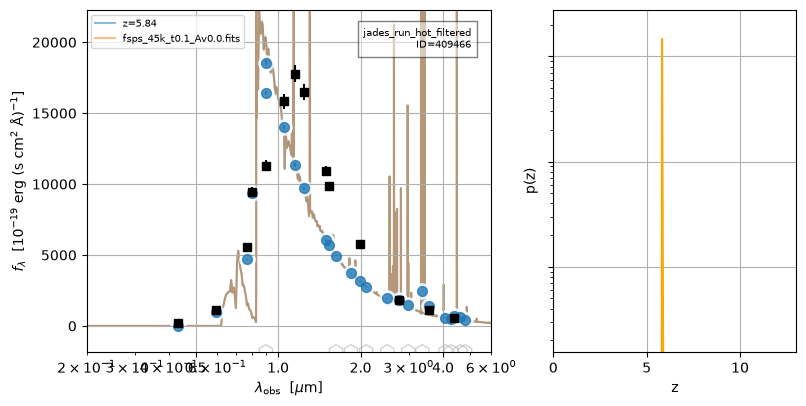

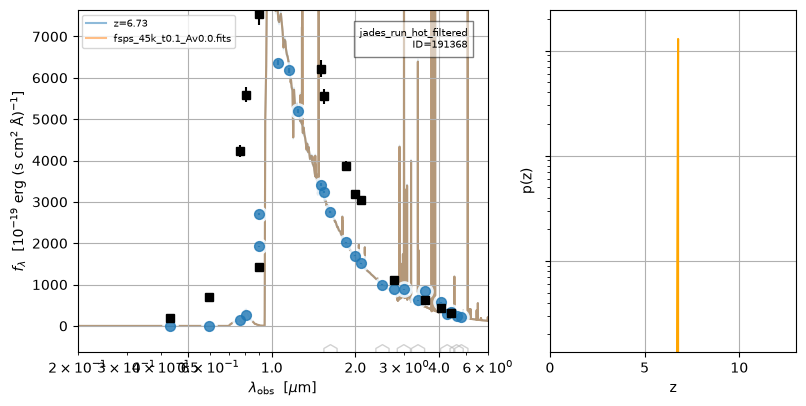

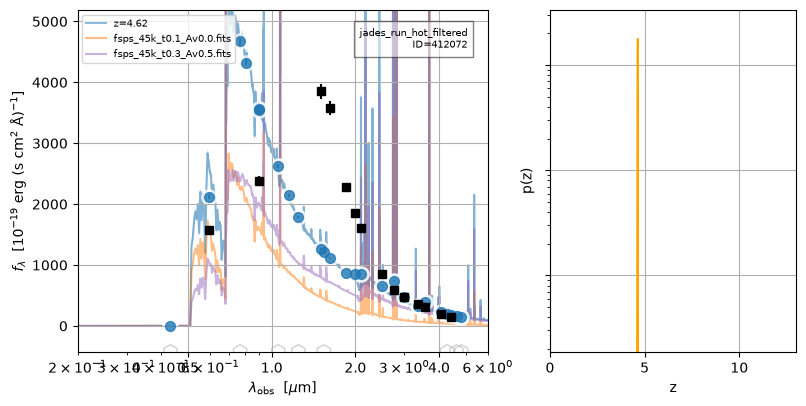

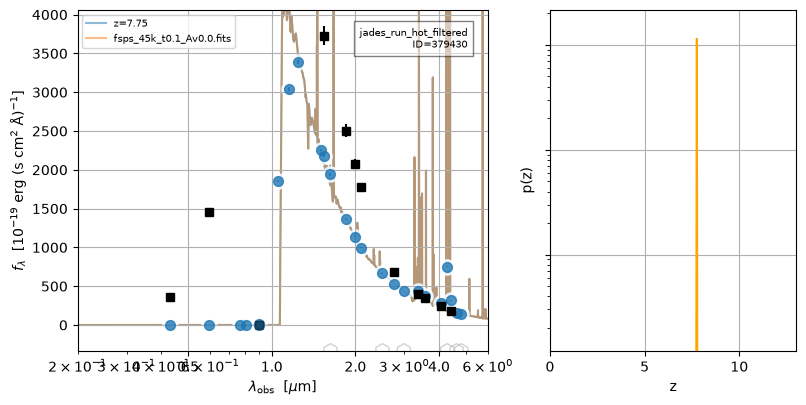

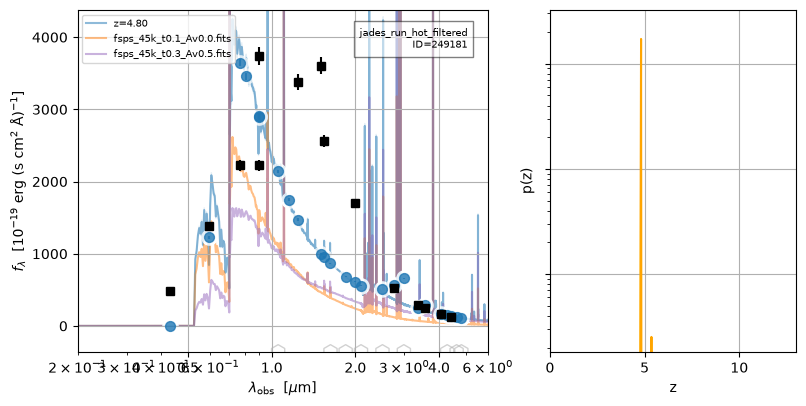

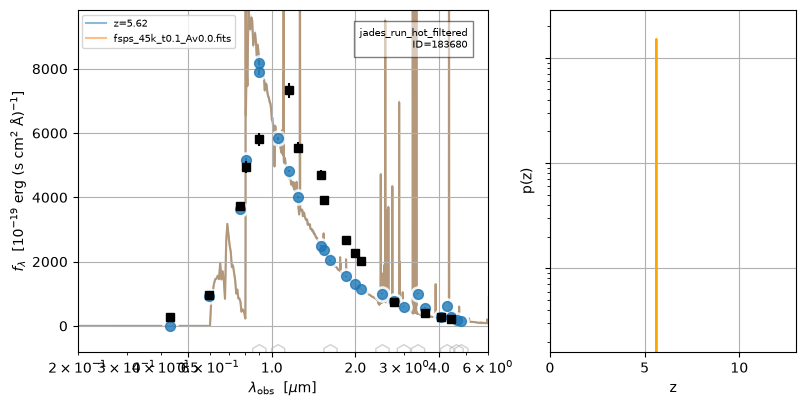

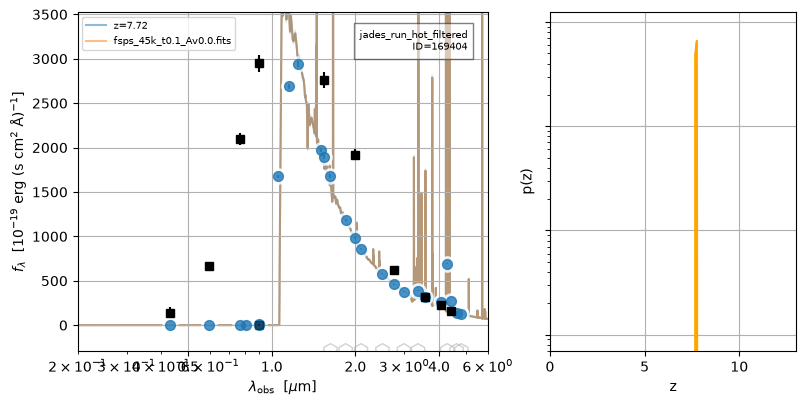

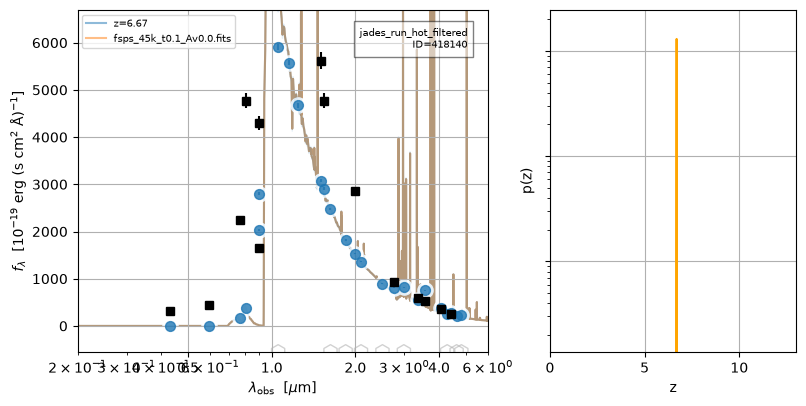

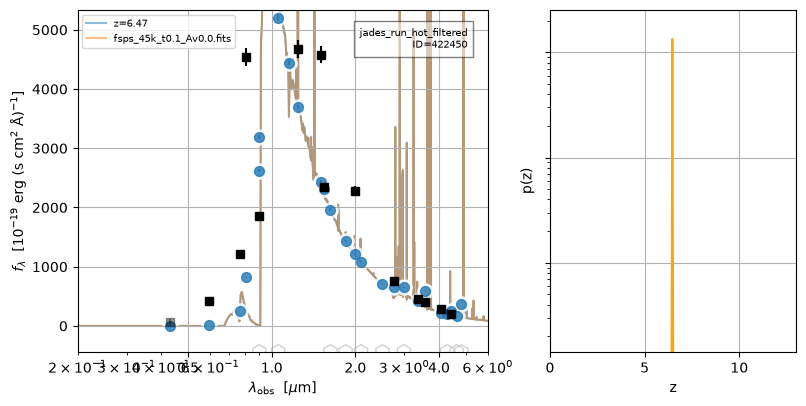

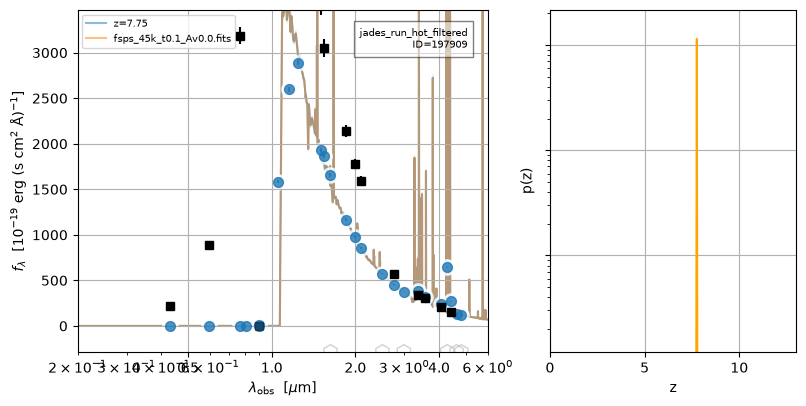

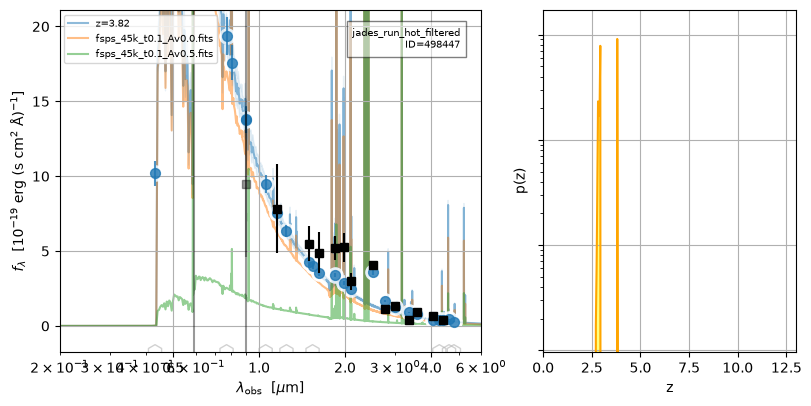

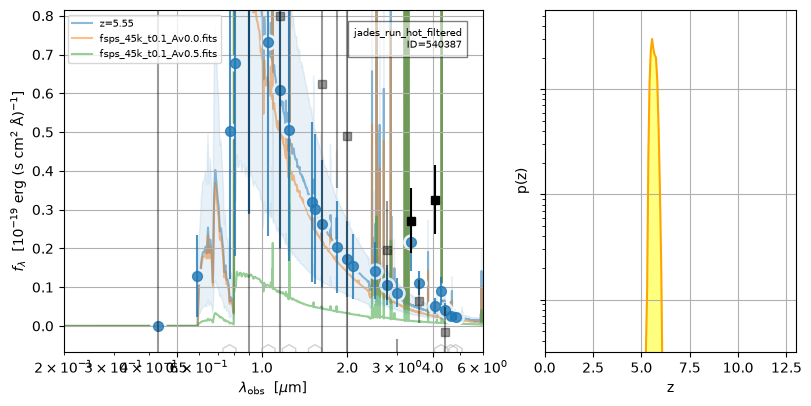

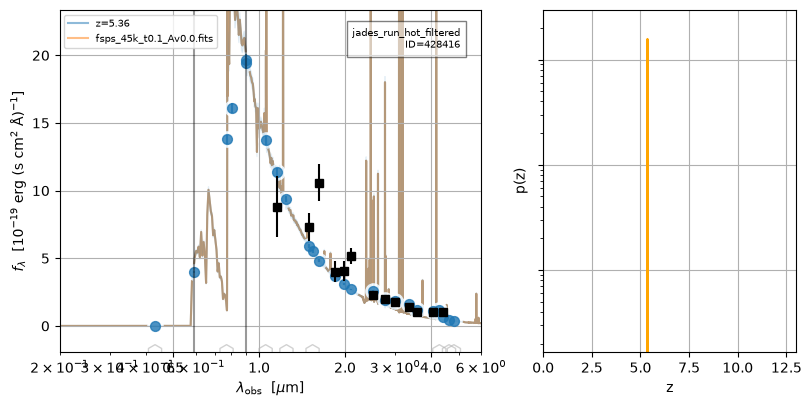

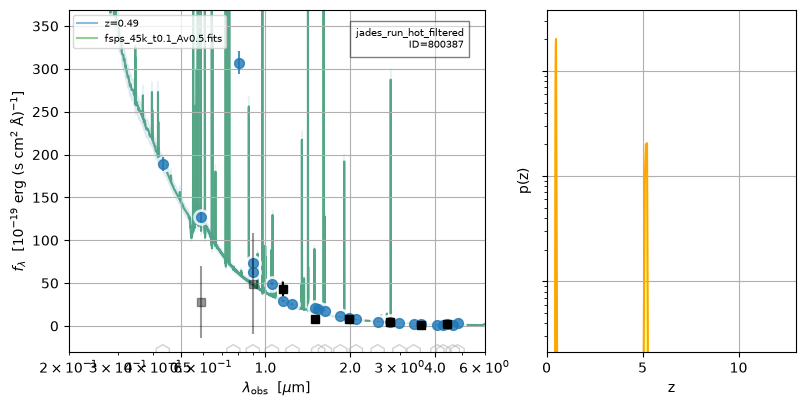

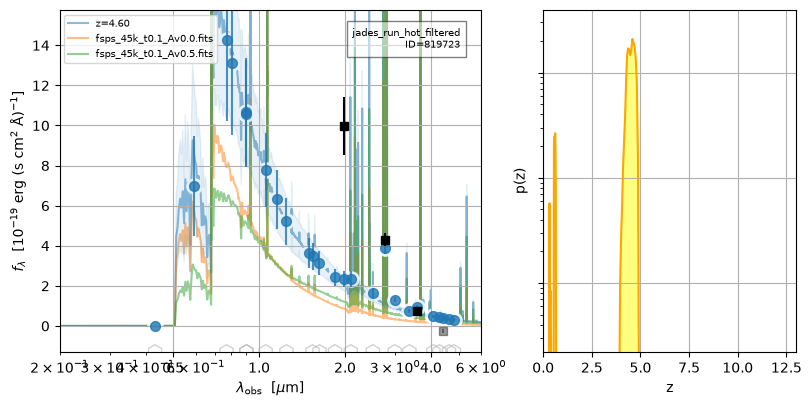

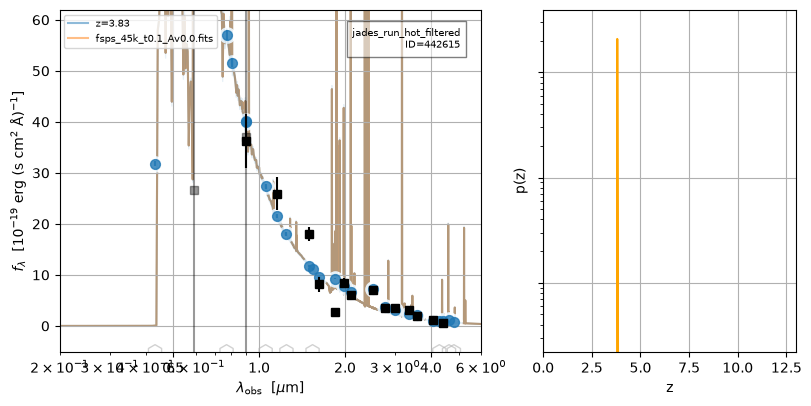

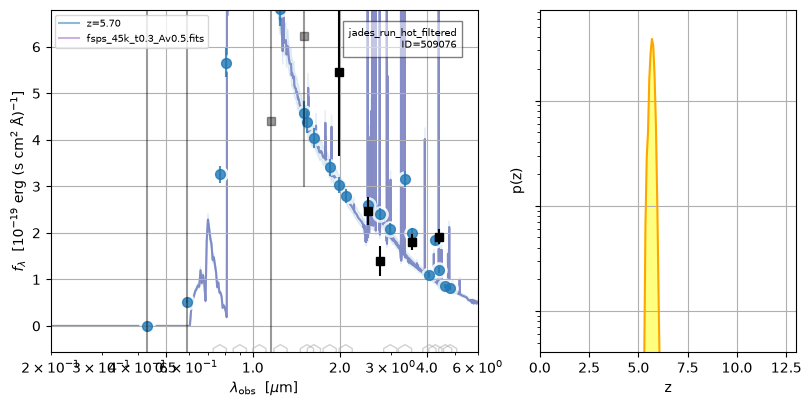

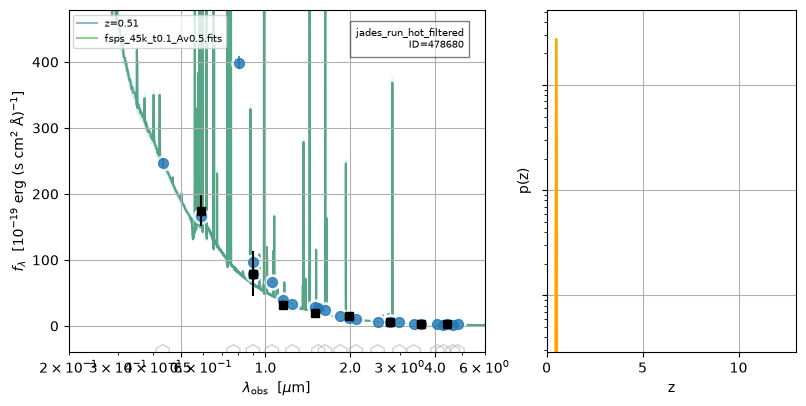

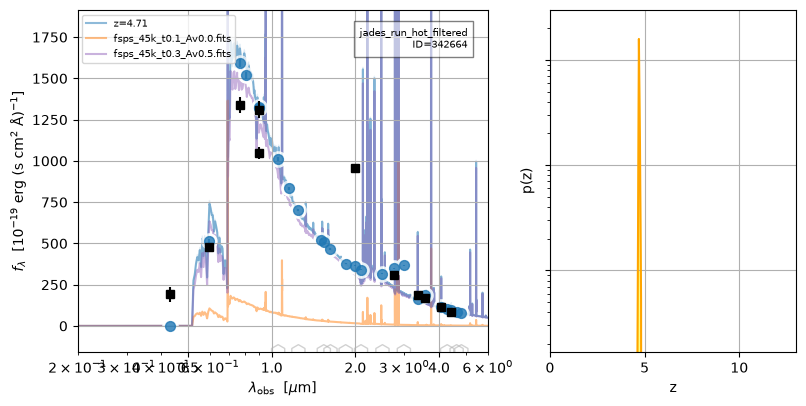

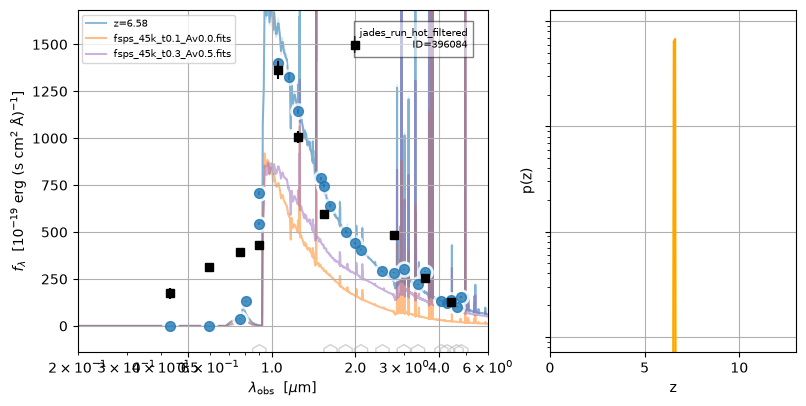

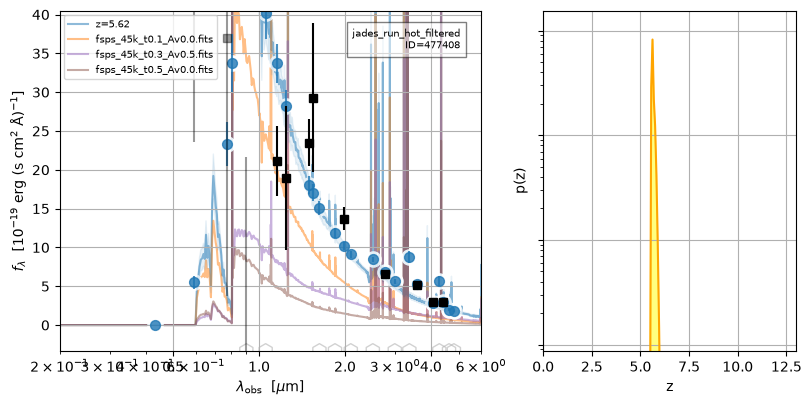

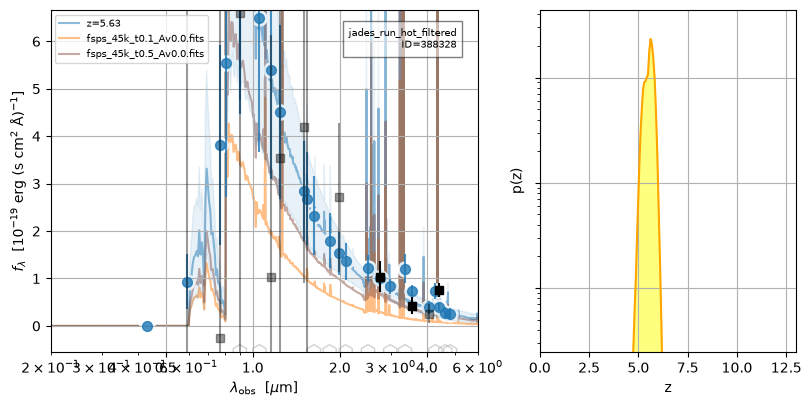

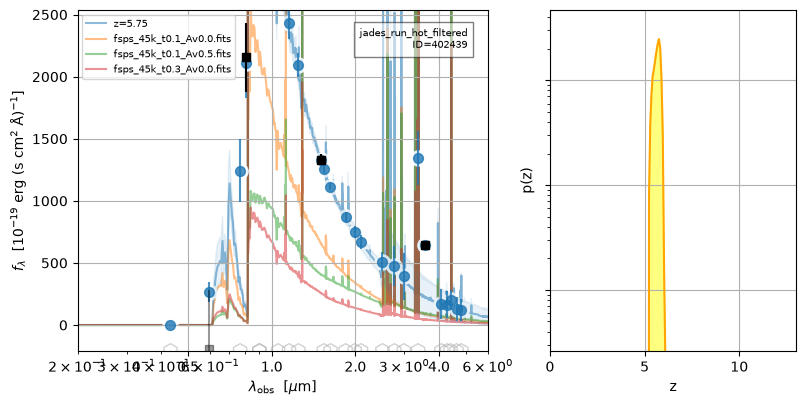

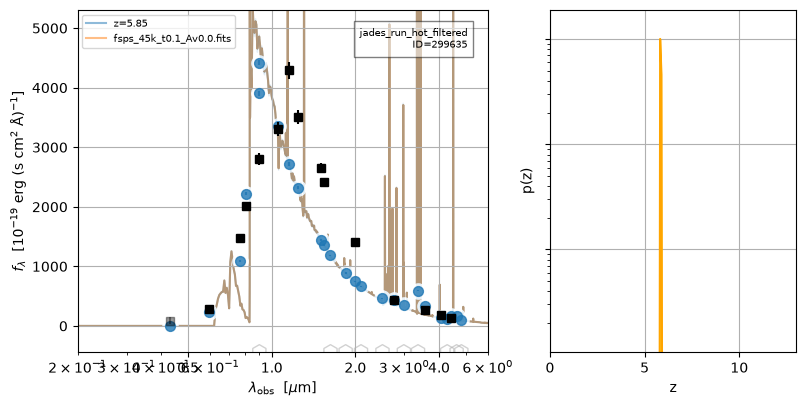

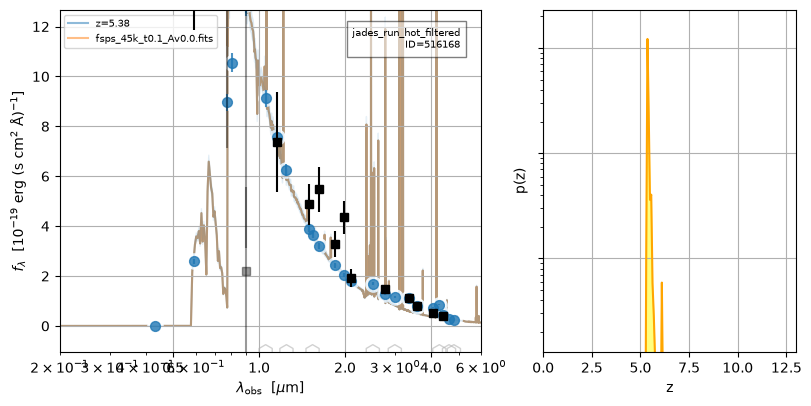

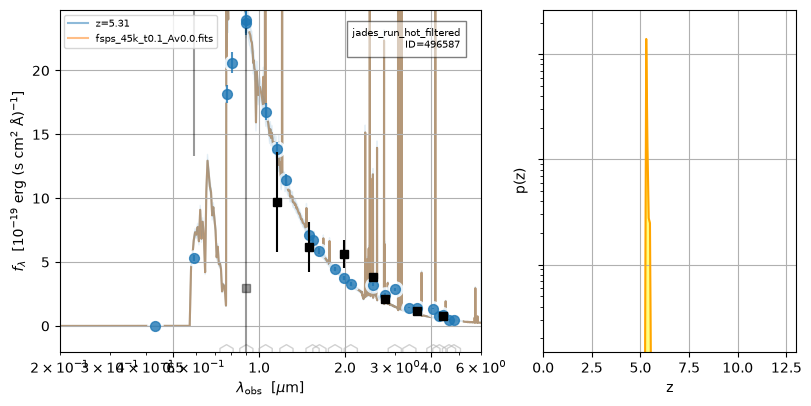

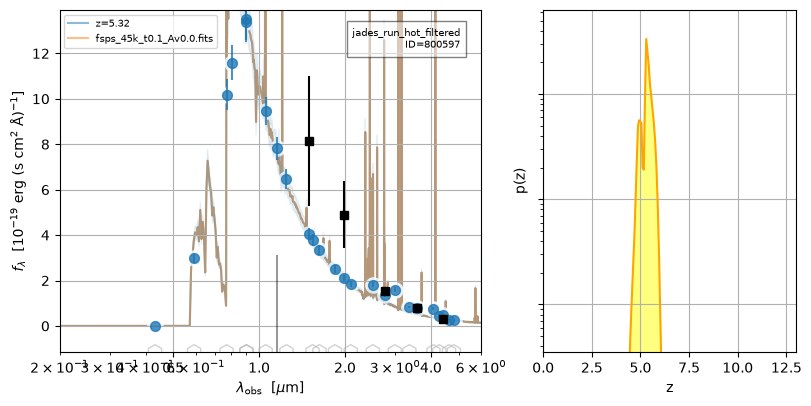

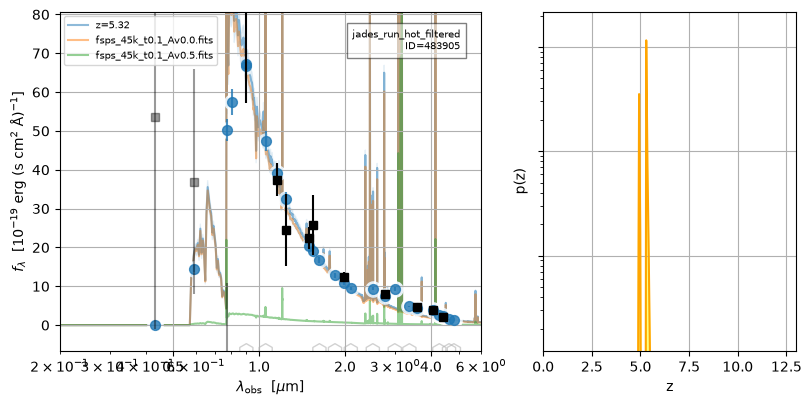

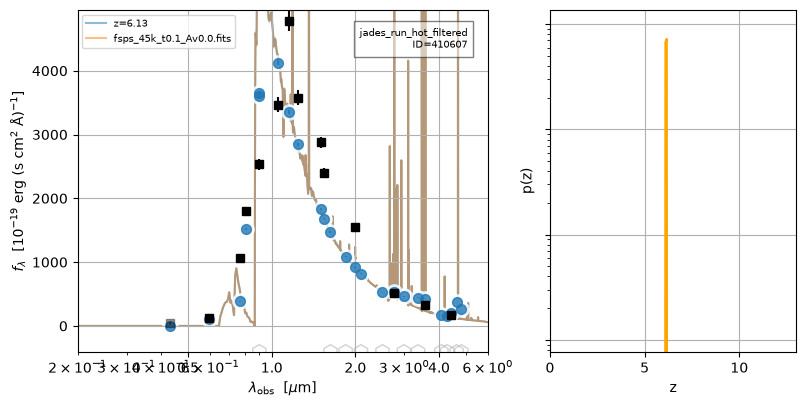

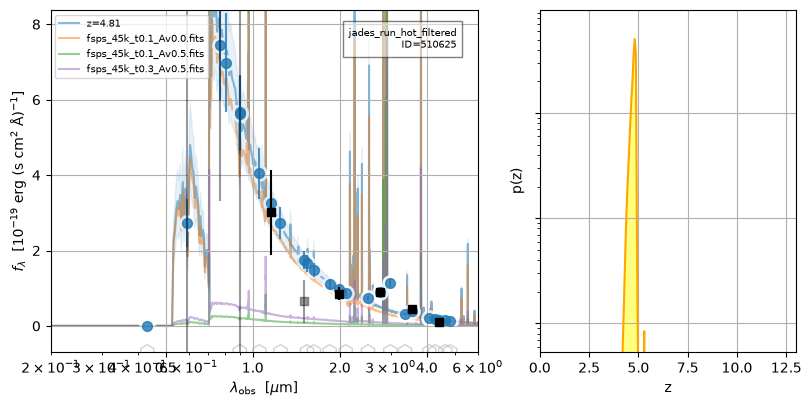

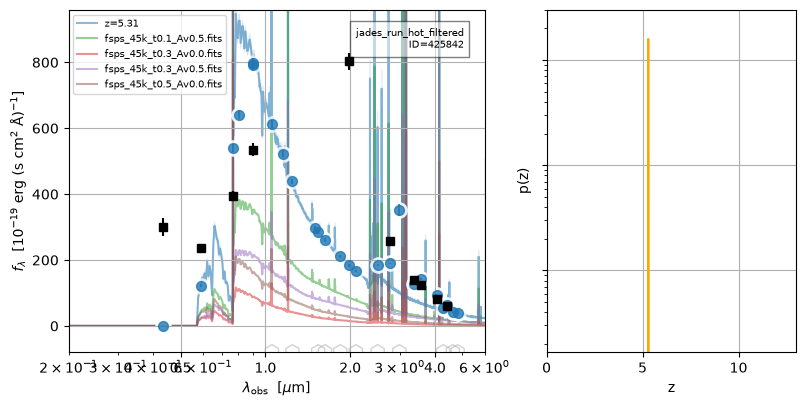

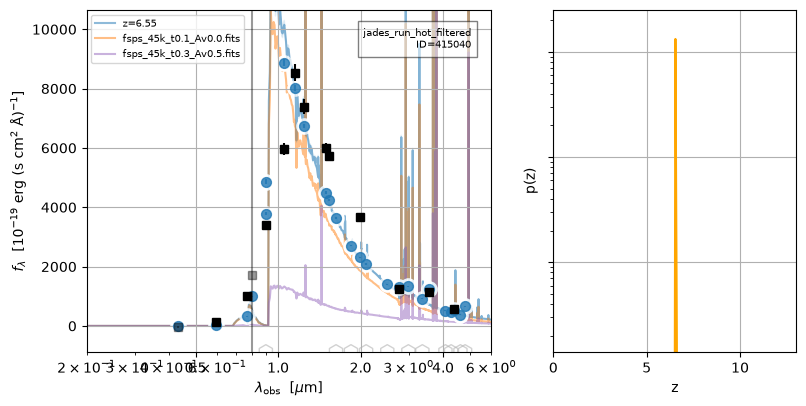

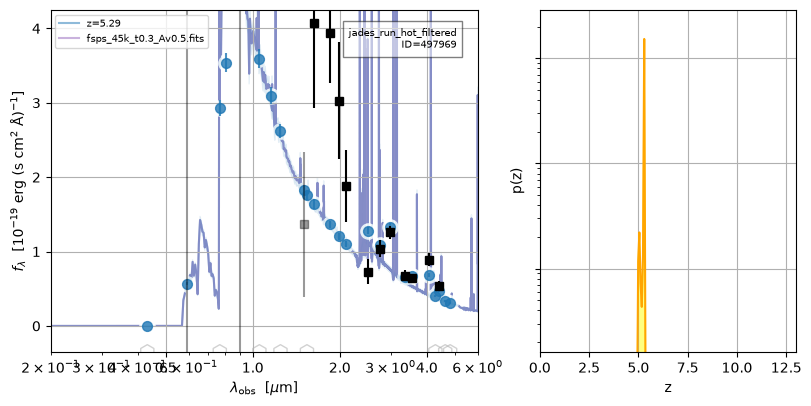

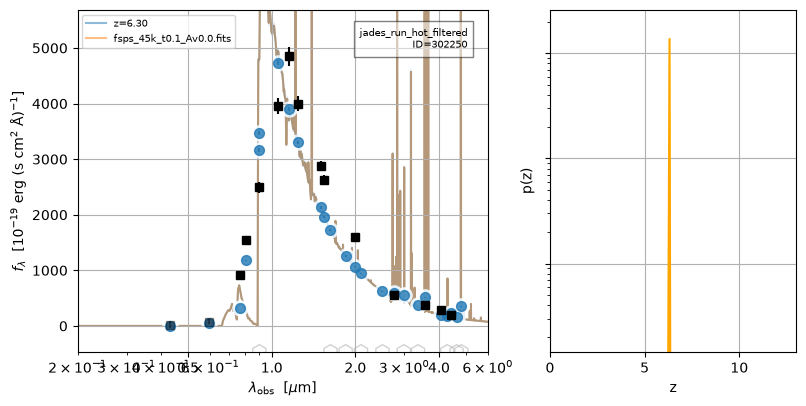

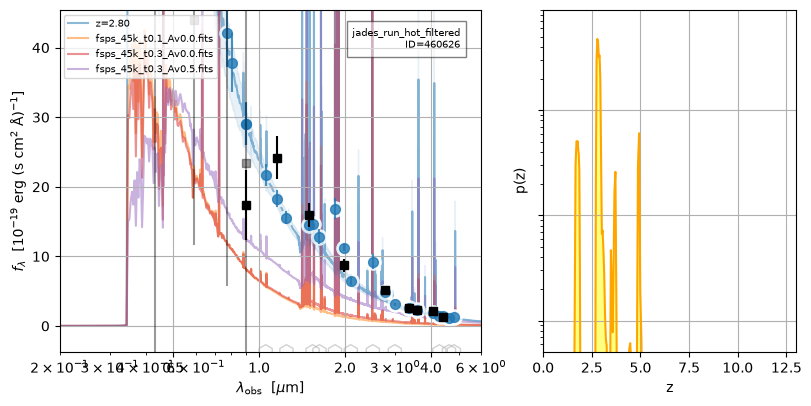

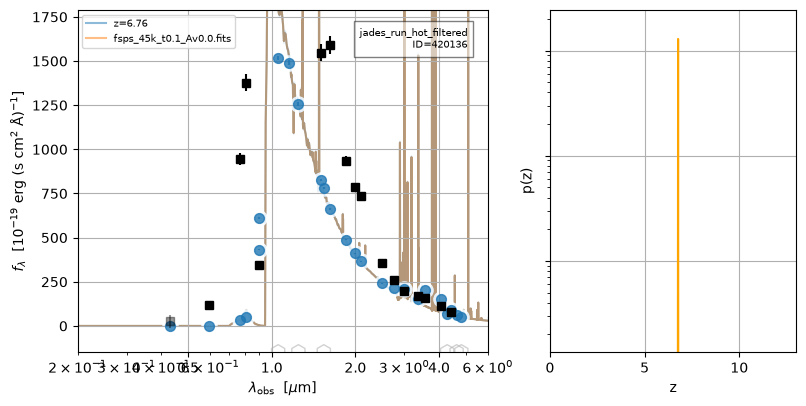

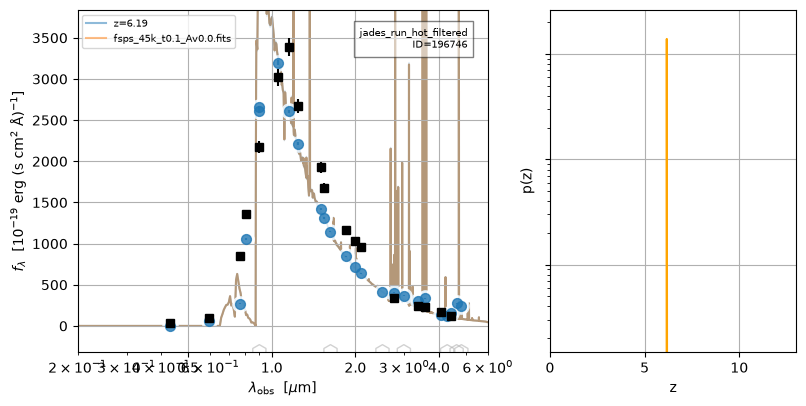

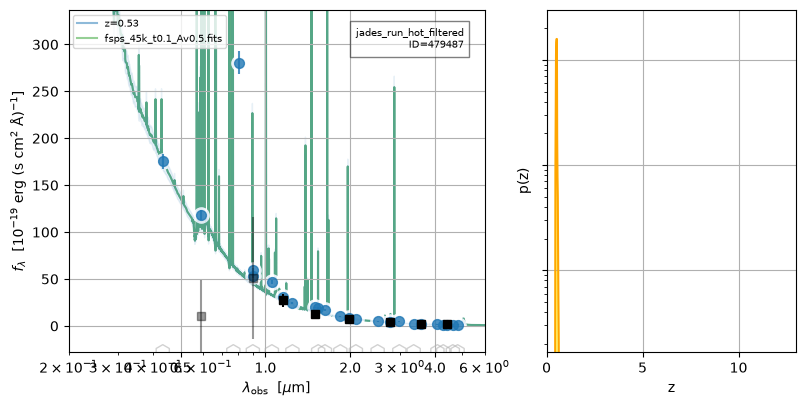

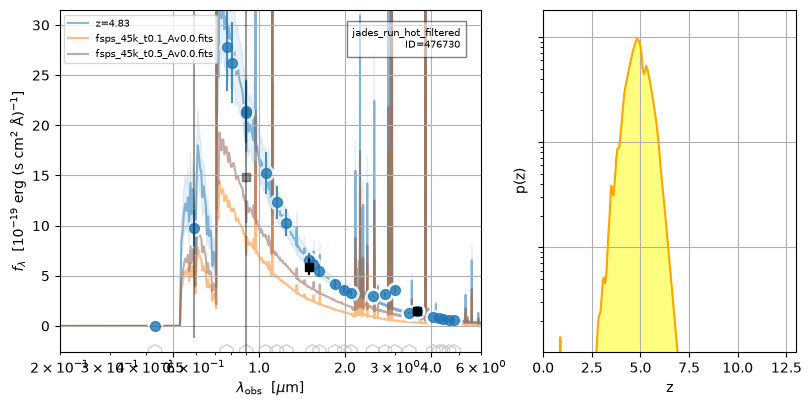

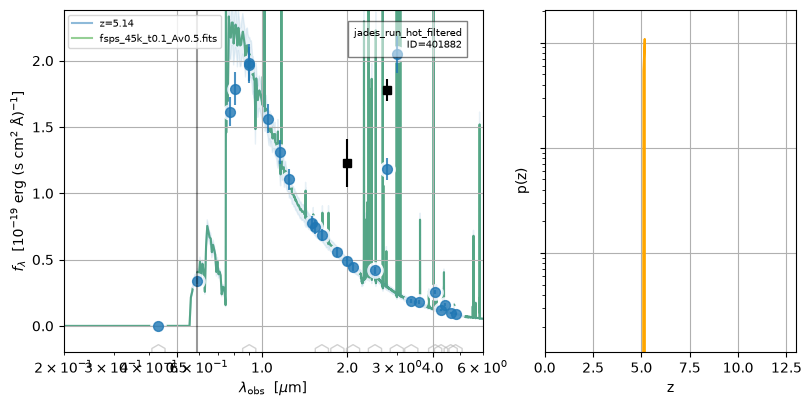

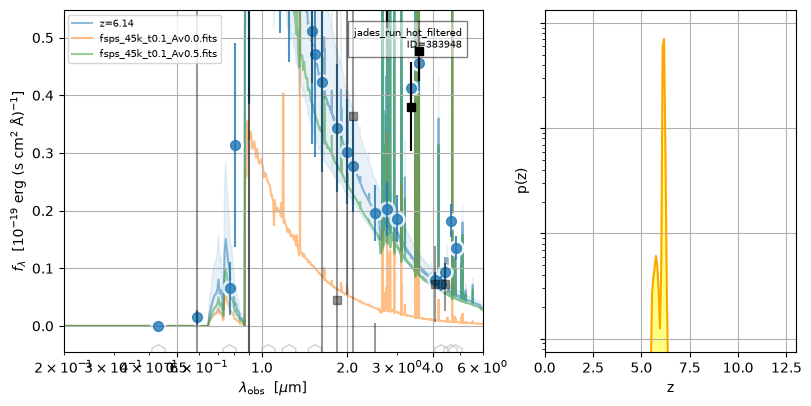

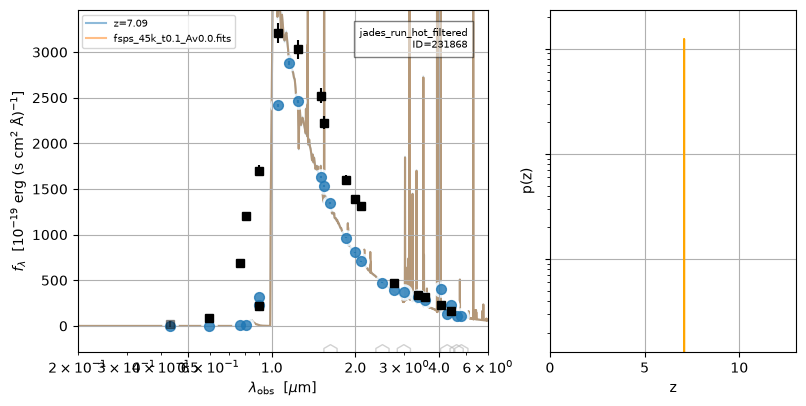

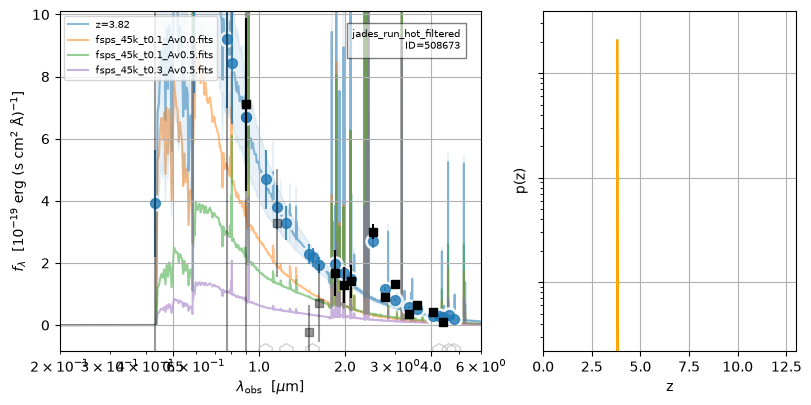

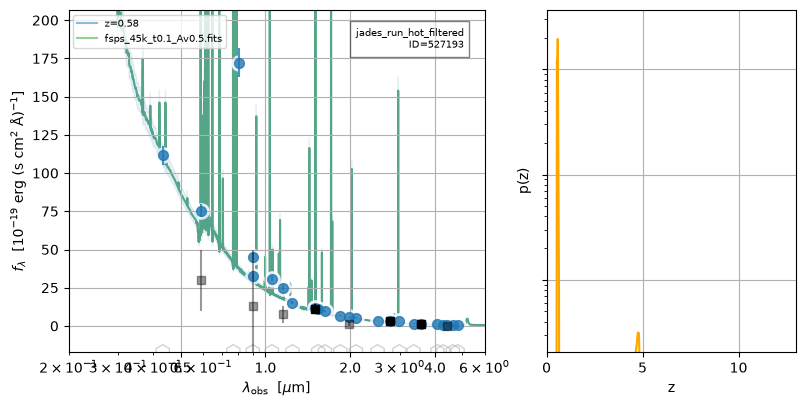

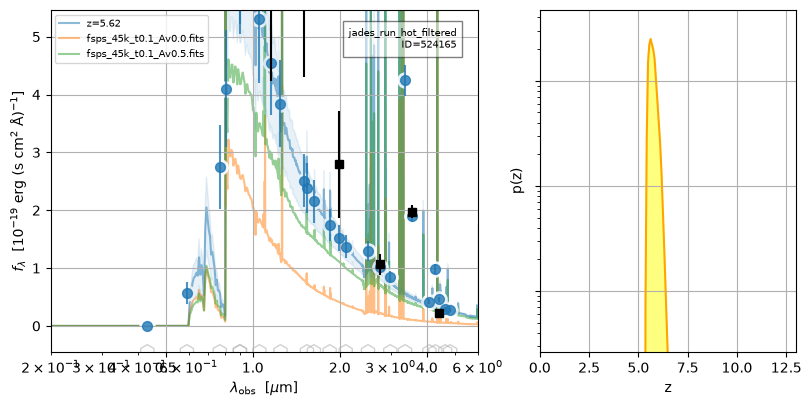

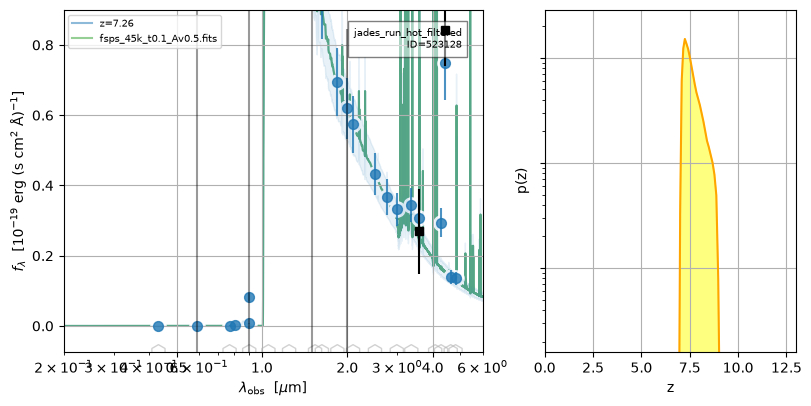

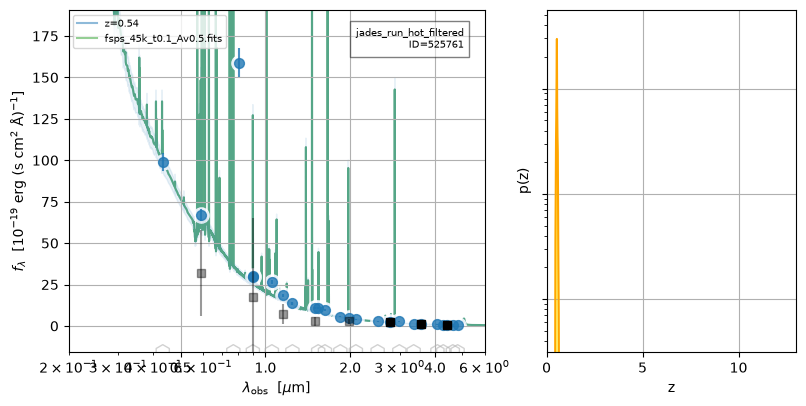

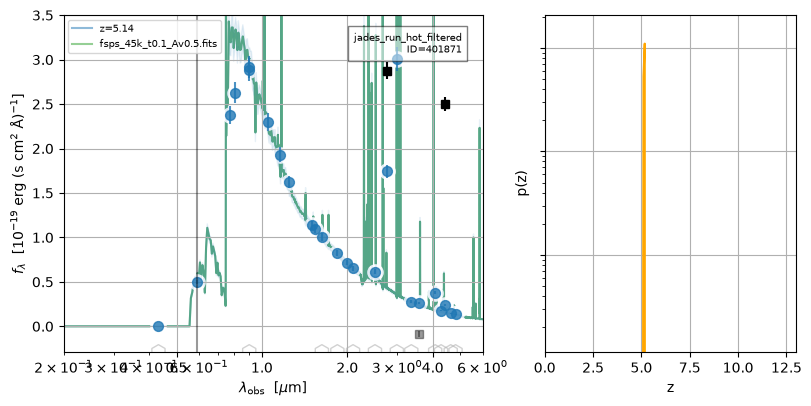

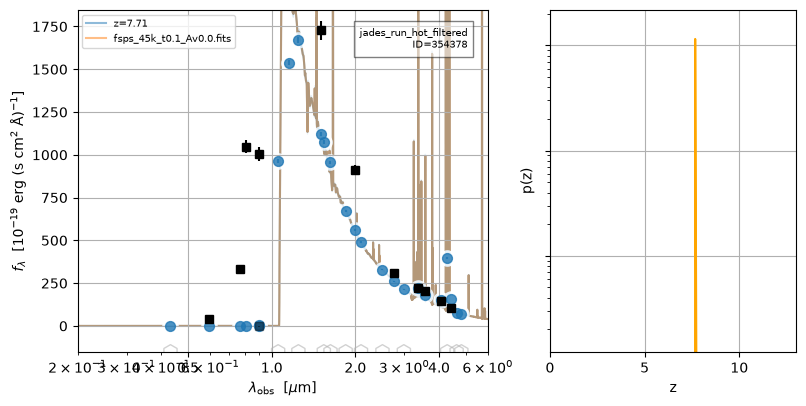

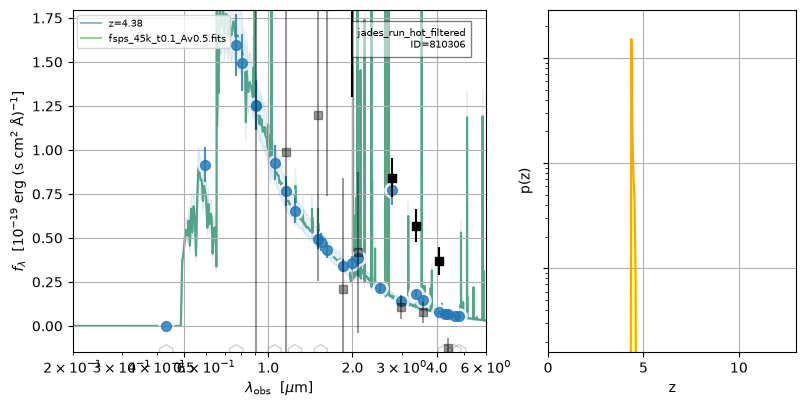

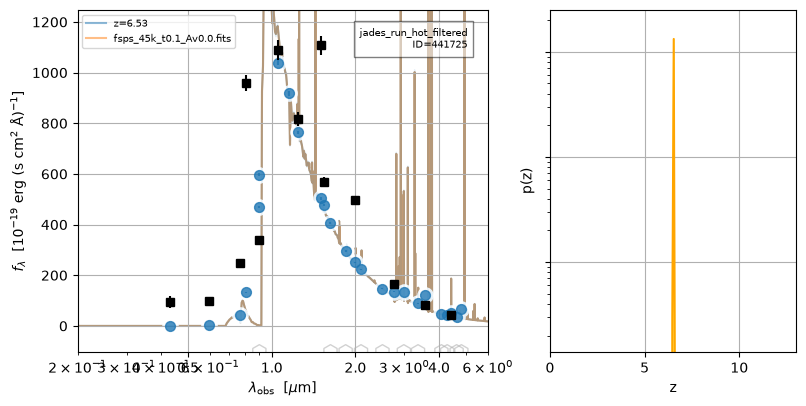

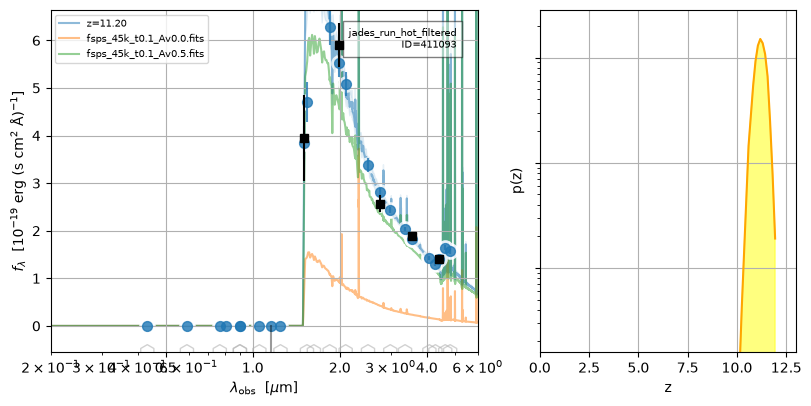

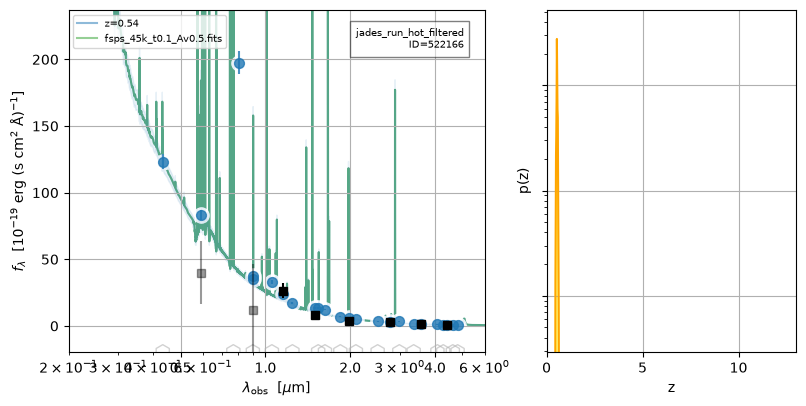

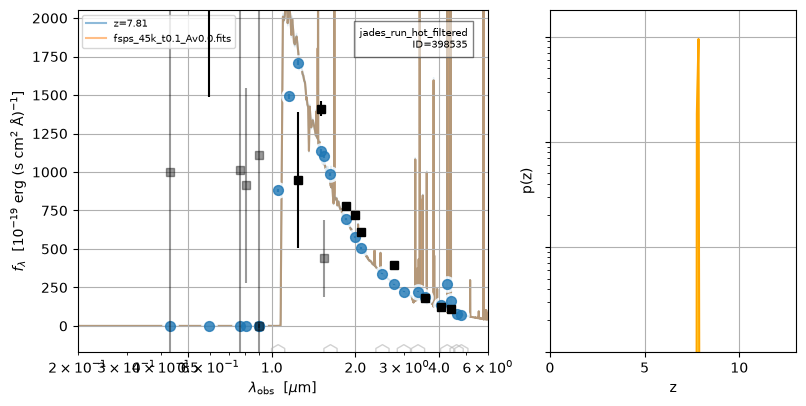

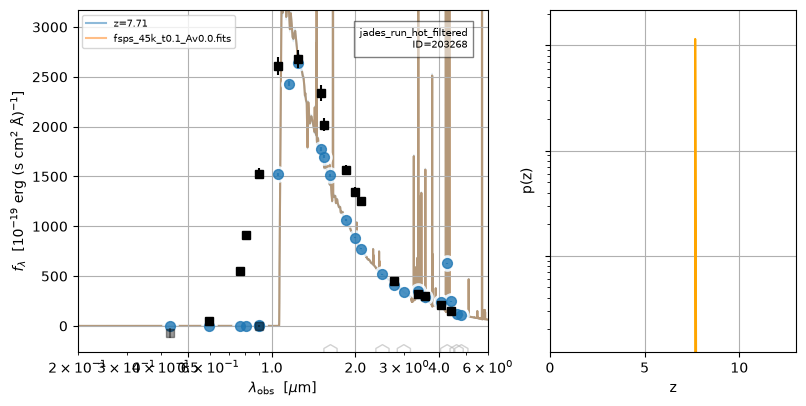

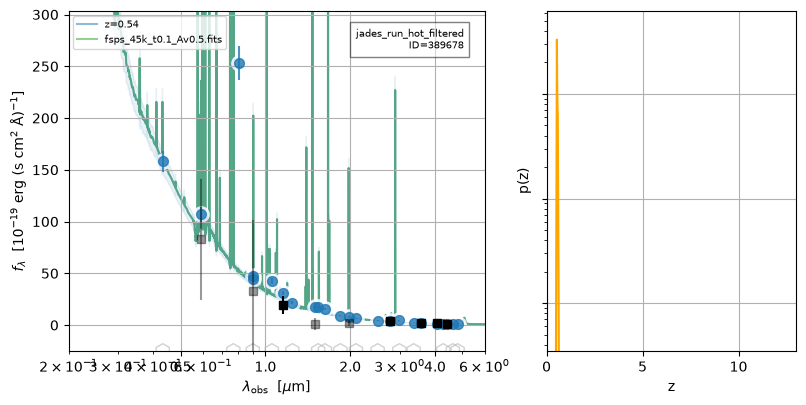

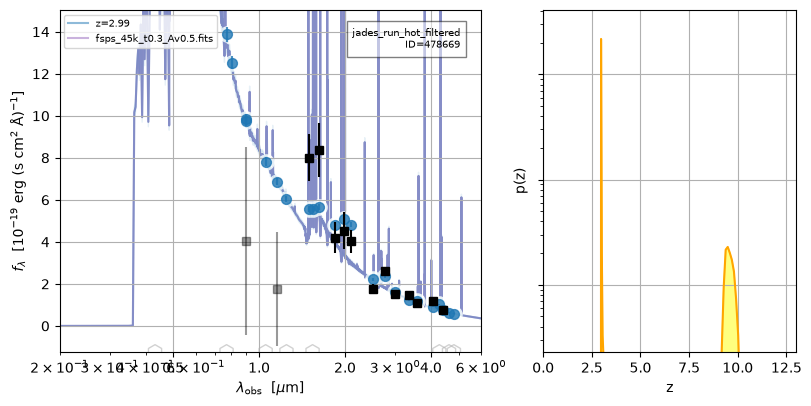

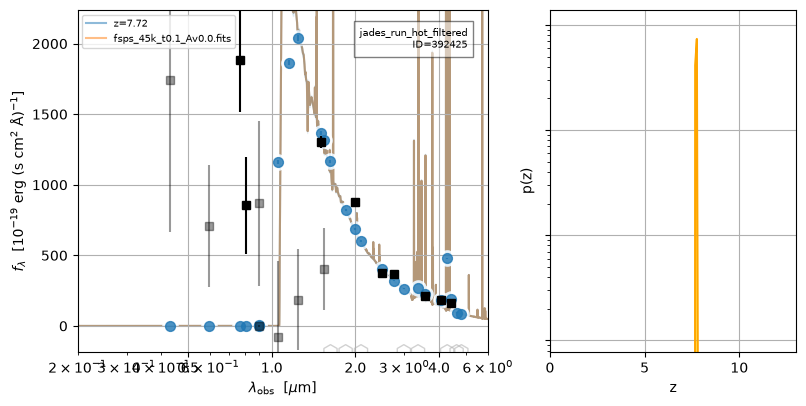

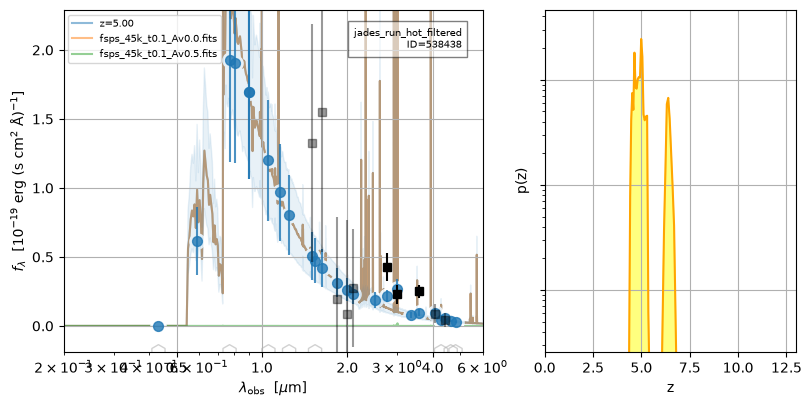

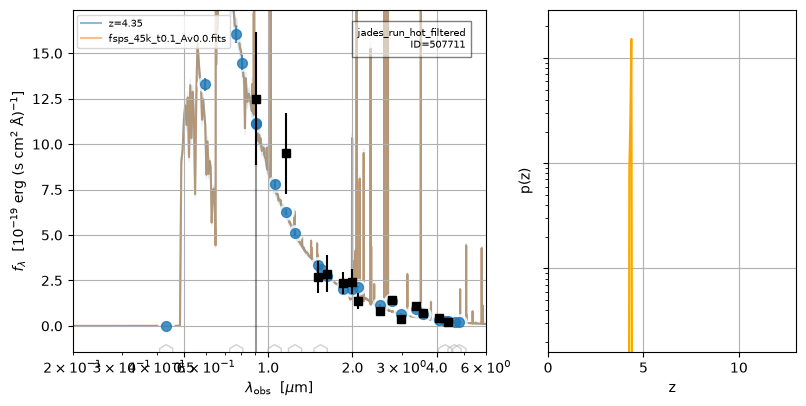

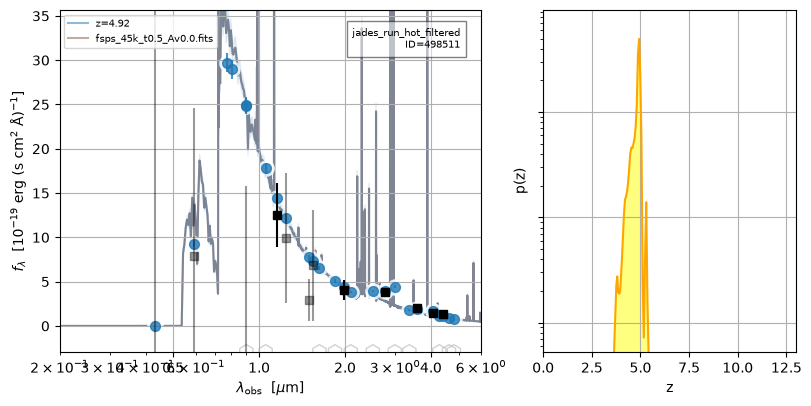

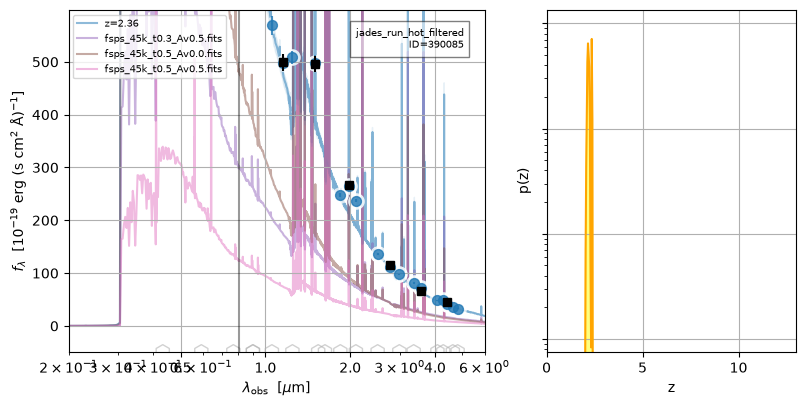

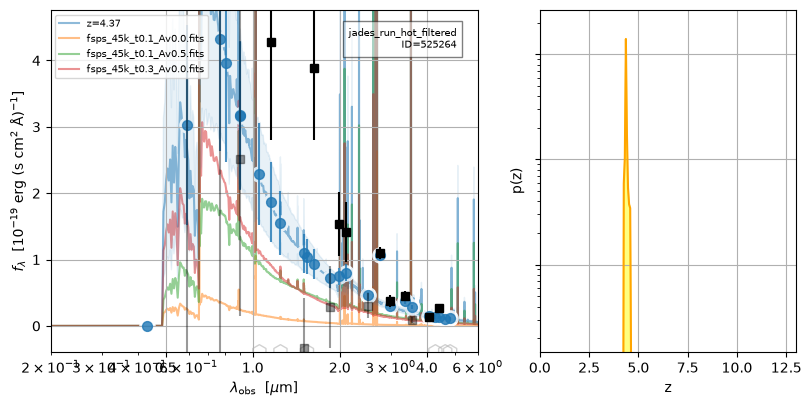

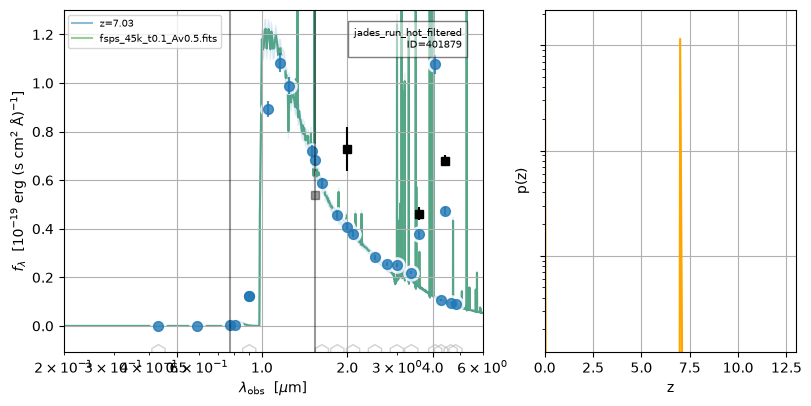

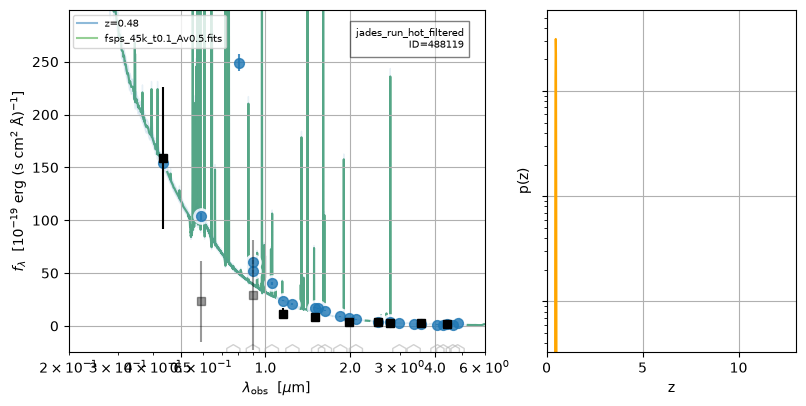

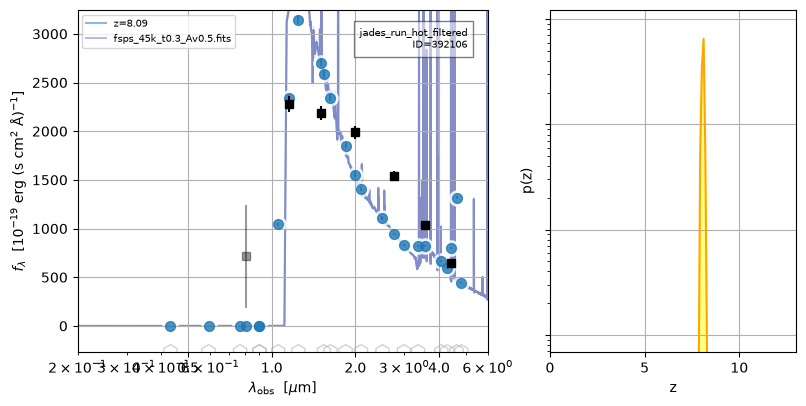

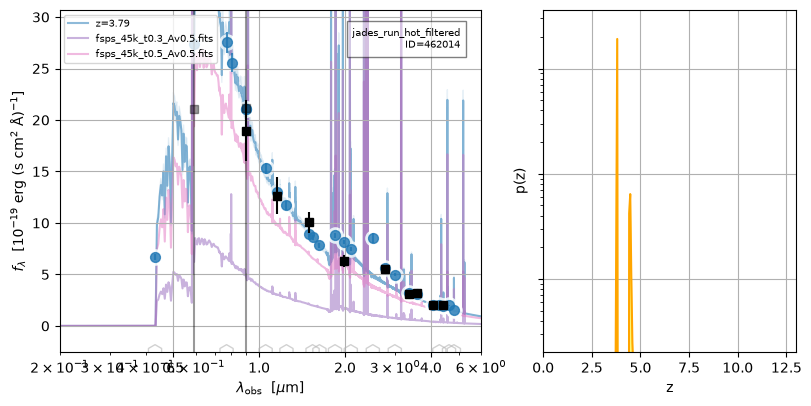

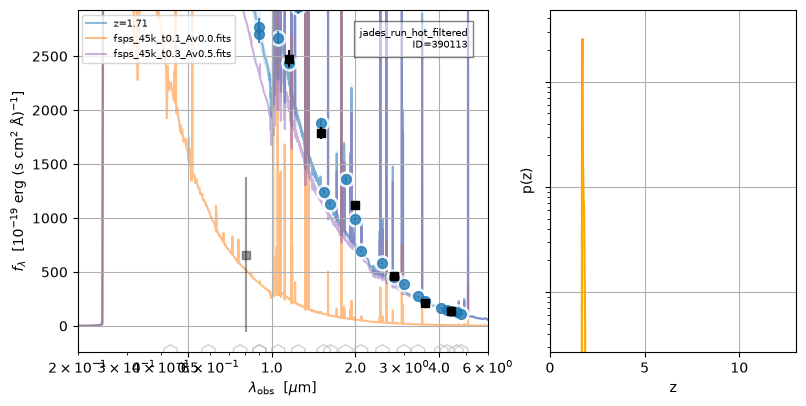

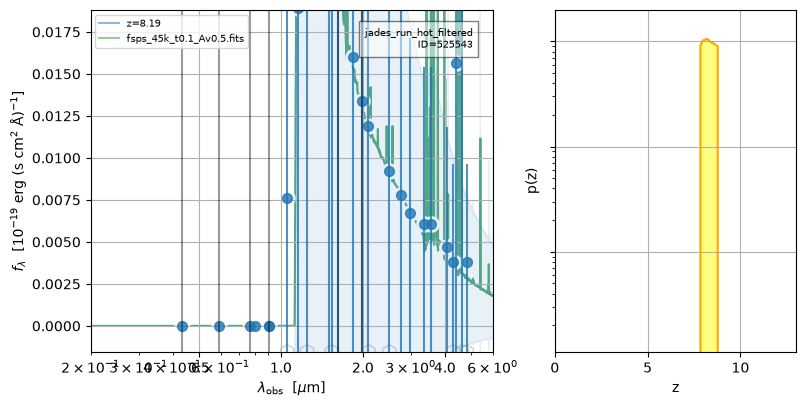

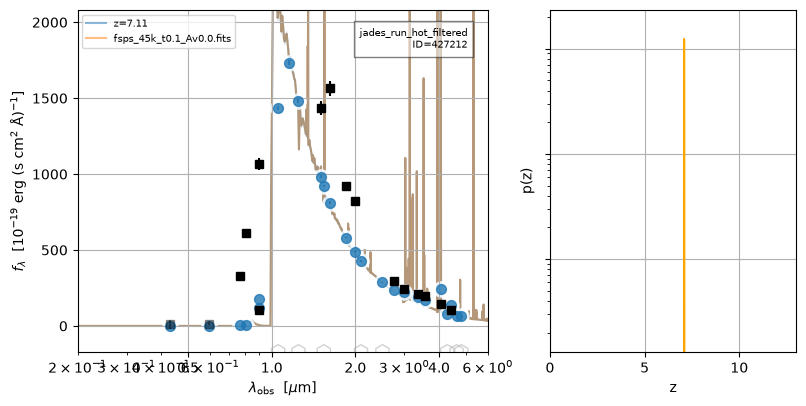

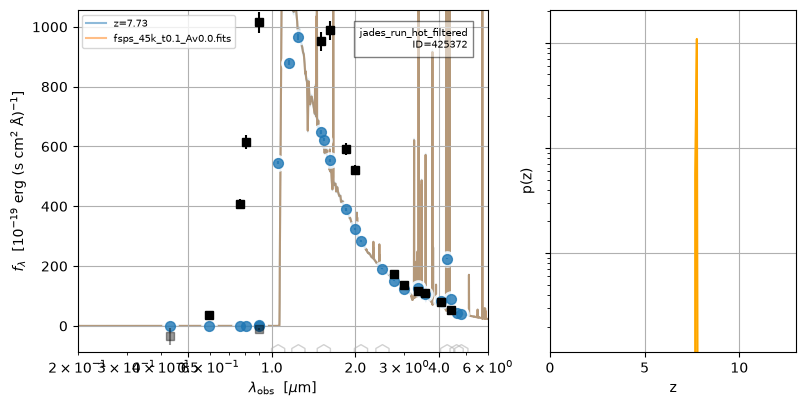

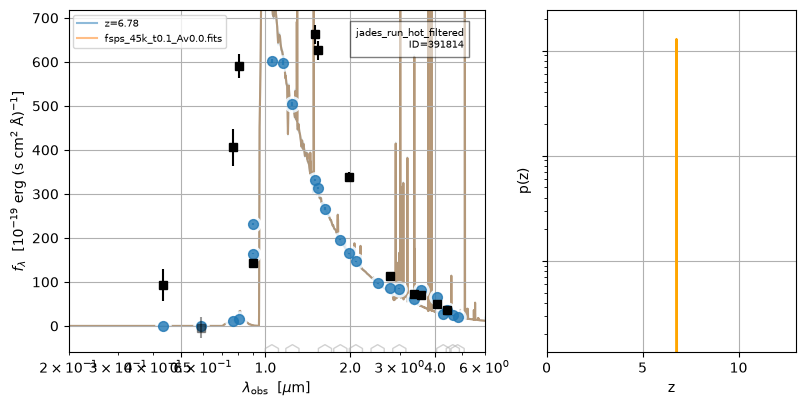

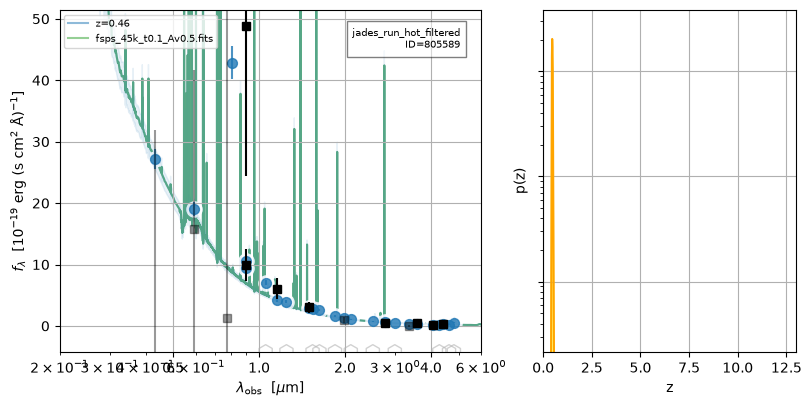

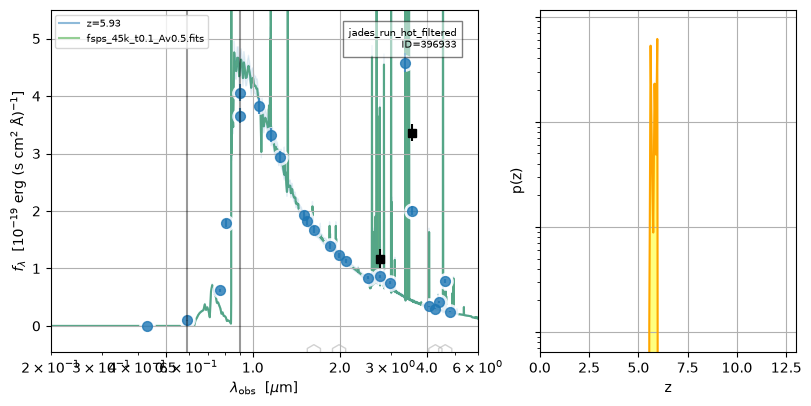

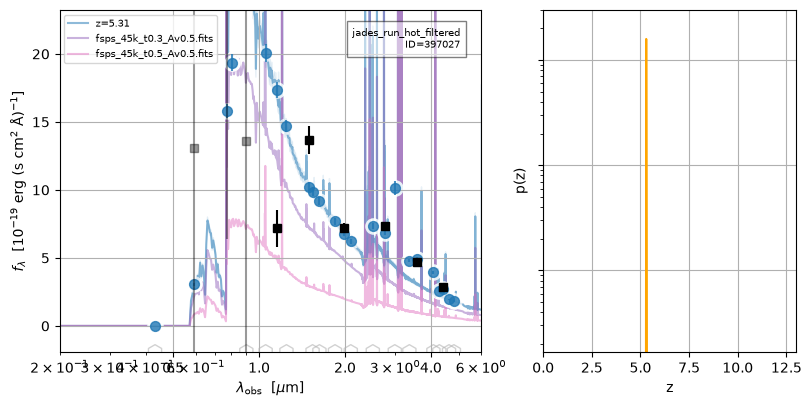

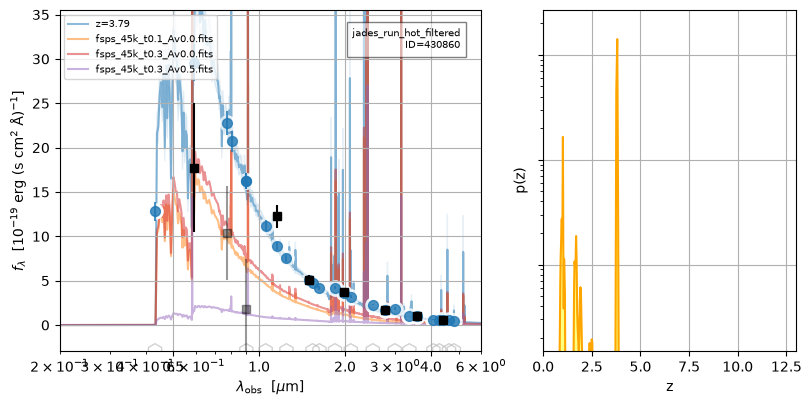

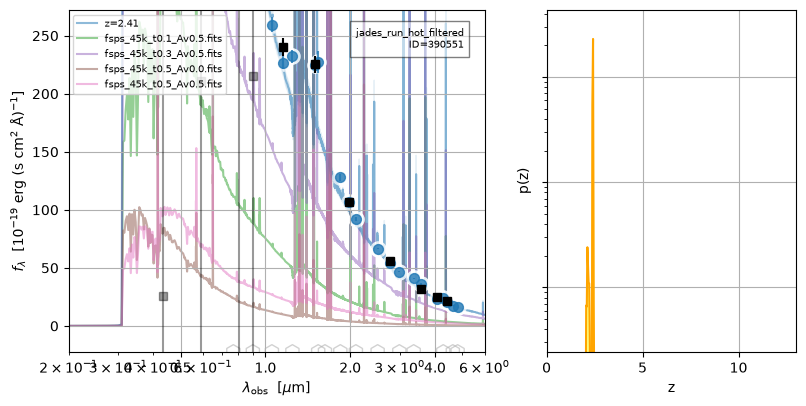

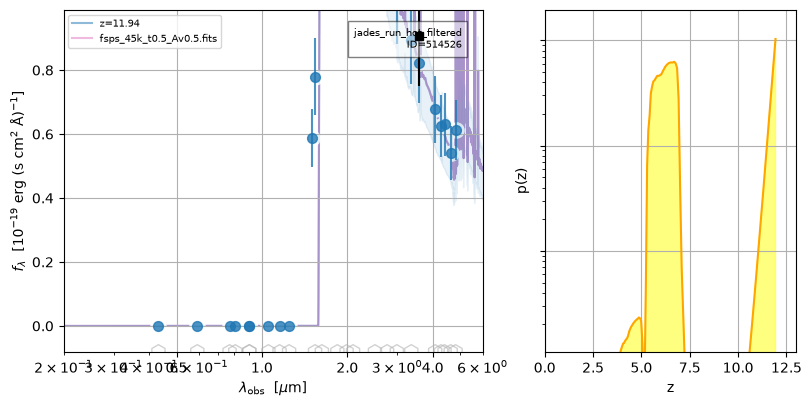

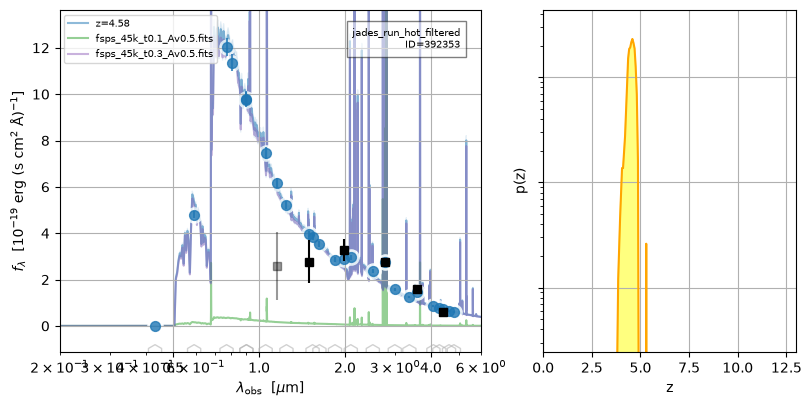

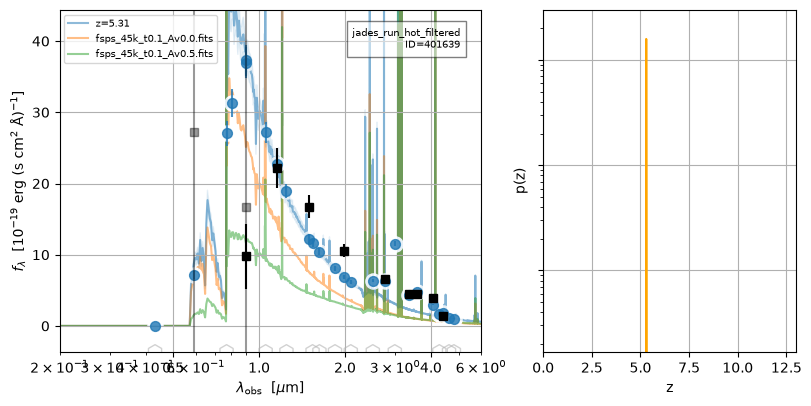

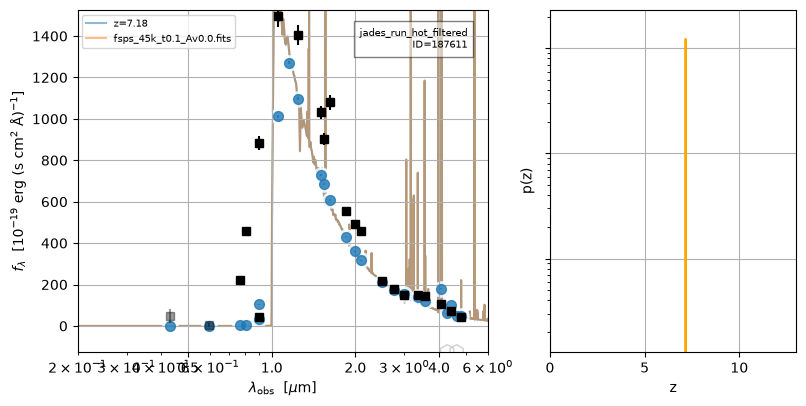

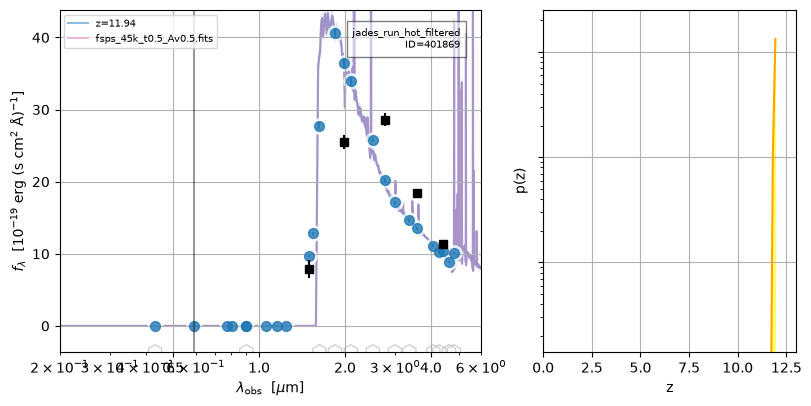

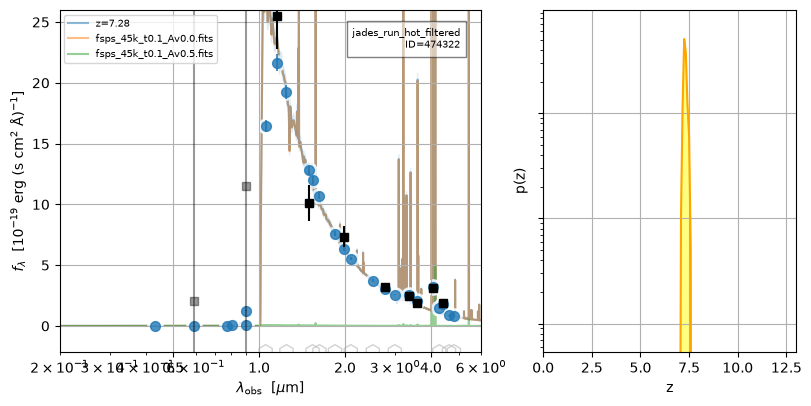

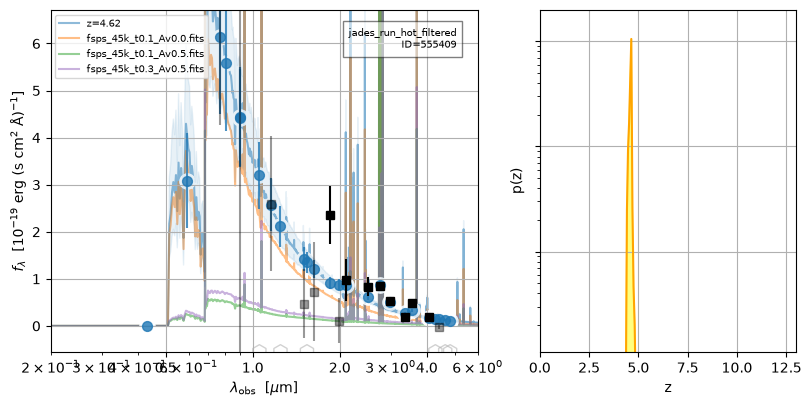

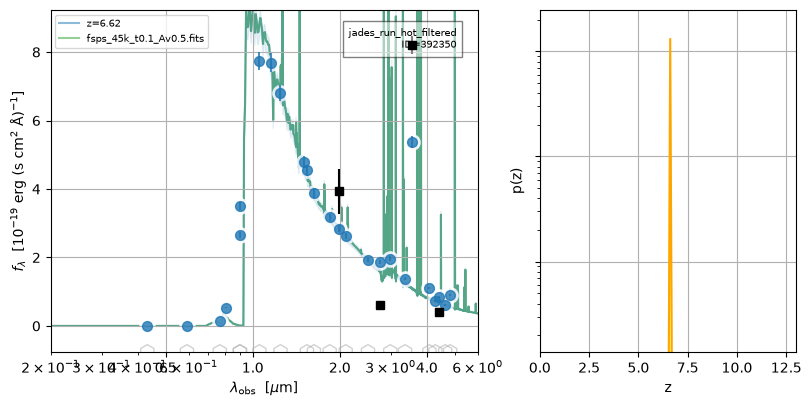

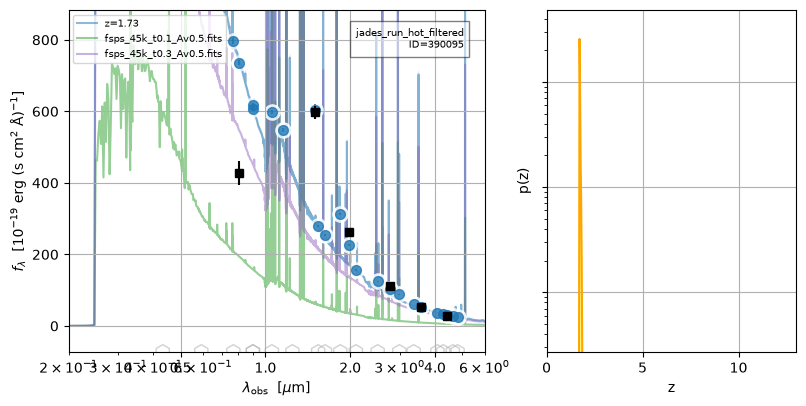

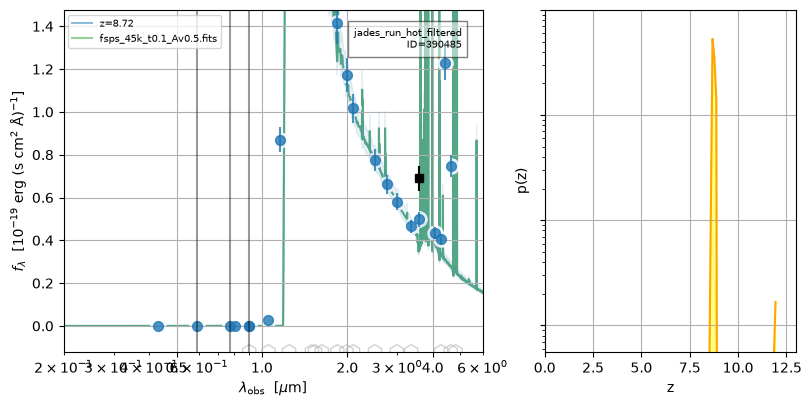

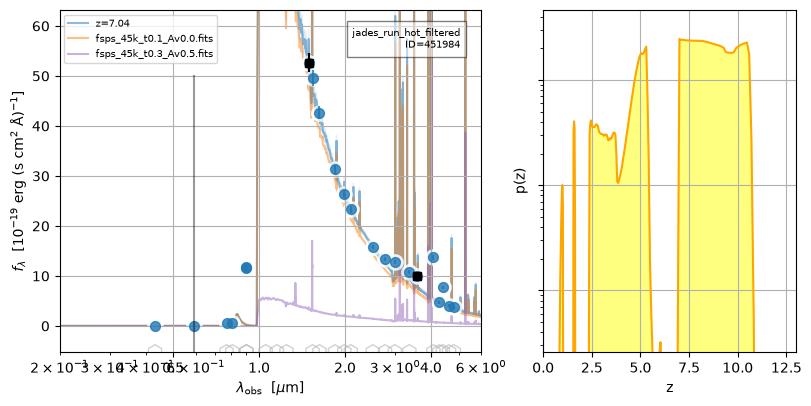

In [27]:
# Show brightest objects with z_spec > 1
n_init = 0
n_final = 30
ifilter = ez.flux_columns[np.argmin((ez.lc - 8140)**2)]

imag = 31.40 - 2.5*np.log10(ez.cat[ifilter])
#sel = (ez.ZPHOTO > 12)

dat1 = '/home/caltech-msanche3/data/SURF2026/scripts/jades_run_hot_filtered.data.fits'
hdul3 = fits.open(dat1,memap=True)
zbest = hdul3[1].data
print(zbest)
sel = zbest > 0

so = np.argsort(imag[sel])
ids = ez.OBJID[sel][so]

for i in range(100):
    fig, data = ez.show_fit(ids[i], xlim=[0.2, 6], show_components=True,
                              logpz=True, zr=[0,13])